# Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy as sc
import scipy.stats as stats
import astropy.cosmology as ac
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numdifftools as nd
import pandas as pd
import sys
import astropy.constants as cst
import random
from matplotlib.patches import Patch
import zeus
from chainconsumer import ChainConsumer
from tqdm import tqdm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from astropy.io import fits
from tqdm.notebook import tqdm
from IPython.display import display, Markdown, Math
from matplotlib import colors

c:\Users\cleam\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\cleam\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
import fisher_matrix_analysis as fma
import basket as ba
import optimisation_functions as opt

In [3]:
# figure size setting for article

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.sans-serif": "Computer Modern Roman",
    "figure.dpi": 300,
    "figure.figsize": (6.1,4.6),  # Put your journal width here
    "savefig.bbox": "tight"})

# 1. Roman mock data

In [4]:
# define cosmological parameters
H0_fid=73
Mb_fid=-19.3
c=float(np.array(cst.c.to('km/s')))


#for flat LCDM, according to Planck 2018 (TT,TE,EE+lowE+lensing)
Om0_fLCDM = 0.3153
Ode0_fLCDM = 1-Om0_fLCDM

#for LCDM
Om0_kLCDM, Ode0_kLCDM = 0.3153, 0.6
Ok0_kLCDM = 1-Om0_kLCDM-Ode0_kLCDM

#for flat wCDM
Om0_fwCDM, w0_fwCDM = 0.3153, -1.029

#for k-wCDM
Om0_kwCDM, Ode0_kwCDM, w0_kwCDM =  0.3153, 0.6, -1.029

#for flat CPL
Om0_fCPL, w0_fCPL, wa_fCPL = 0.3153, -1.029, 0.21

#for CPL
Om0_kCPL, Ode0_kCPL, w0_kCPL, wa_kCPL = 0.3153, 0.6, -1.029, 0.21

#for PEDE
Om0_PEDE, Ode0_PEDE = 0.3153, 0.6
Ok0_PEDE=1-Om0_PEDE-Ode0_PEDE

fiducial_fLCDM  = [Om0_fLCDM,Mb_fid]

fiducial_kLCDM = [Om0_kLCDM, Ode0_kLCDM, Mb_fid]


fiducial_fwCDM = [Om0_fwCDM, w0_fwCDM, Mb_fid]

fiducial_kwCDM = [Om0_kwCDM, Ode0_kwCDM, w0_kwCDM,Mb_fid]

fiducial_fCPL=[Om0_fCPL,w0_fCPL,wa_fCPL,Mb_fid]
 
# fiducial cosmologie
#LCDM
cosmo_fLCDM = ac.FlatLambdaCDM(H0=H0_fid,Om0=Om0_fLCDM)
cosmo_kLCDM = ac.LambdaCDM(H0=H0_fid,Om0=Om0_fLCDM,Ode0=Ode0_fLCDM)

#wCDM
cosmo_fwCDM = ac.FlatwCDM(H0=H0_fid,Om0=Om0_fLCDM,w0=w0_fwCDM)
cosmo_kwCDM = ac.wCDM(H0=H0_fid,Om0=Om0_kwCDM,Ode0=Ode0_kwCDM,w0=w0_kwCDM)

#CPL
cosmo_fCPL=ac.Flatw0waCDM(H0=H0_fid,Om0=Om0_fCPL,w0=w0_fCPL,wa=wa_fCPL)

In [5]:
# Roman data

roman = pd.read_csv('roman_data/mock_roman.csv', sep=';')
z_roman = roman.z.values
dist_roman = roman.Nstar.values
#dist_roman = np.full_like(np.array(z_roman),200) # fake flat distribution
cov = fits.getdata("roman_data/roman_cov.fits")

# last row is the redshifts -> no it is th efirst one actually
Cov_roman = cov[1:, :]  
II = np.eye(Cov_roman.shape[0])
Cov_inv_roman = np.linalg.solve(Cov_roman, II)
sigma_roman = np.sqrt(np.diag(Cov_roman))

# define bin edges
edges_mid = 0.5 * (z_roman[1:] + z_roman[:-1])
# first and last edges
first_edge = z_roman[0] - (edges_mid[0] - z_roman[0])
last_edge  = z_roman[-1] + (z_roman[-1] - edges_mid[-1])

# combine
z_edges = np.concatenate([[first_edge], edges_mid, [last_edge]])

In [6]:
fma.is_positive_definite(Cov_roman)

True

In [7]:
# Cov_roman_stat = np.diag(np.diag(Cov_roman))
# Cov_roman_sys  = Cov_roman - Cov_roman_stat

In [8]:
off_diagonal = Cov_roman-np.diag(np.diag(Cov_roman))
Cov_roman_sys = off_diagonal.copy()

n = off_diagonal.shape[0]

for i in range(n):
    # only diagonal elements
    # (since matrix is square, i == j)
    
    # define neighborhood
    i_min = max(i - 1, 0)
    i_max = min(i + 2, n)

    submatrix = off_diagonal[i_min:i_max, i_min:i_max]

    # build global indices
    rows, cols = np.indices(submatrix.shape)
    global_rows = rows + i_min
    global_cols = cols + i_min

    # keep only OFF-diagonal elements (global condition)
    mask = global_rows != global_cols
    values = submatrix[mask]

    Cov_roman_sys[i, i] = values.mean()

Cov_roman_stat = Cov_roman-Cov_roman_sys

In [9]:
fma.is_positive_definite(Cov_roman_stat), fma.is_positive_definite(Cov_roman)

(True, True)

In [10]:
# Mock noisy data
mock_roman = np.load('roman_data/NGR_fLCDM.npz')
mb_roman = mock_roman['mb']

In [11]:
# roman cost
tt = ba.T_ngrt(z_roman)
tt.shape

(59,)

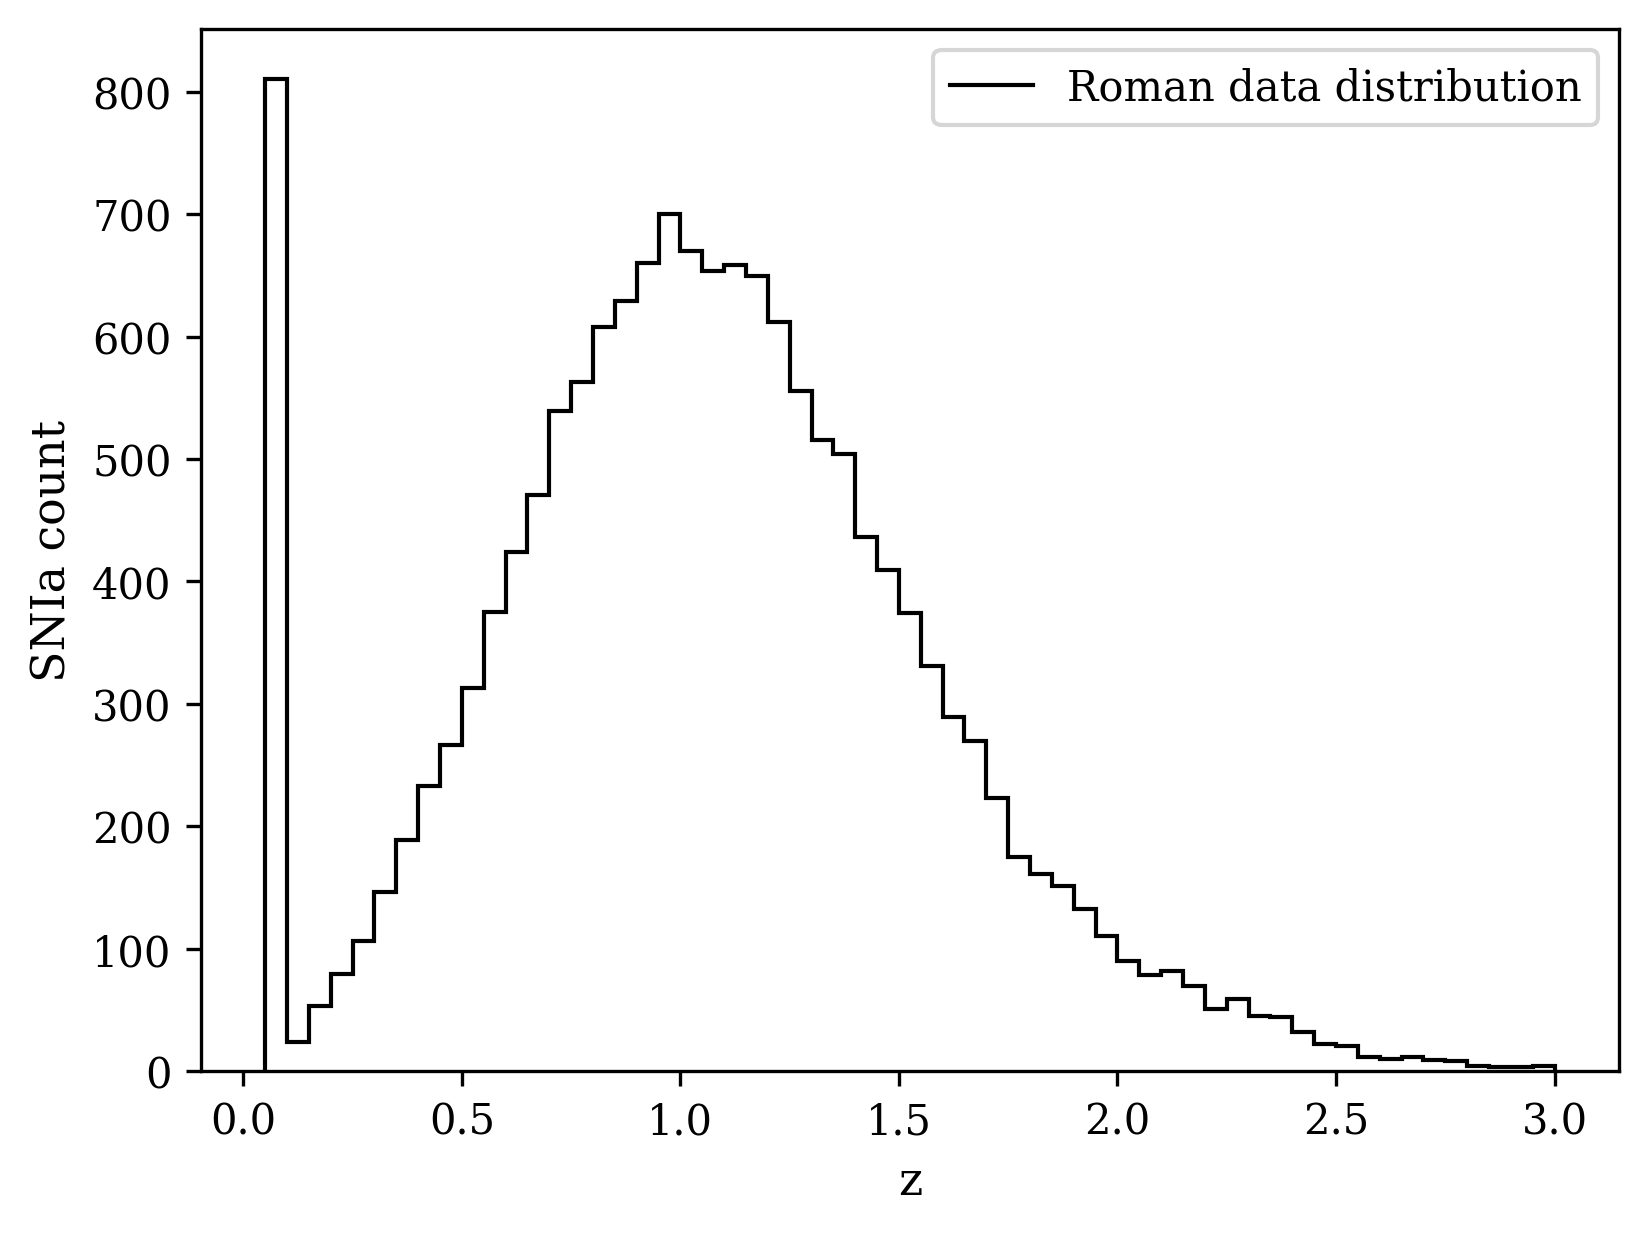

In [12]:
# Estimate bin edges

# plot
plt.stairs(dist_roman, z_edges, label="Roman data distribution", color="black")
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
##plt.savefig("figures/roman_data_distribution")
plt.show()

In [13]:
dist_roman

array([811,  24,  53,  79, 106, 146, 189, 233, 266, 313, 375, 424, 471,
       539, 563, 608, 629, 660, 700, 670, 654, 659, 650, 612, 556, 516,
       504, 436, 409, 374, 331, 289, 270, 223, 175, 161, 151, 132, 110,
        90,  78,  82,  69,  51,  59,  45,  44,  32,  22,  20,  11,  10,
        11,   9,   8,   4,   3,   3,   4], dtype=int64)

In [14]:
bin_size = z_roman[1] - z_roman[0]
obs_time_roman = (dist_roman * tt).sum()

display(Markdown(rf"""
<div style="border:1px solid #999; padding:10px; border-radius:6px">

**Roman Survey Data Overview**

- Total number of Type Ia supernovae: {dist_roman.sum():,.0f}  
- Redshift bin size: $\Delta z = {bin_size:.3f}$  
- Total number of bins: {len(z_roman)}  
- Redshift range: ${z_roman.min() - bin_size/2:.3f} \leq z \leq {z_roman.max() + bin_size/2:.3f}$  
- Total observation time: {obs_time_roman/(3600*24):.2f} days  
- Mean error on $m_\mathrm{{B}}$: {np.sqrt(np.diag(Cov_roman)).mean():.2f}  

</div>
"""))


<div style="border:1px solid #999; padding:10px; border-radius:6px">

**Roman Survey Data Overview**

- Total number of Type Ia supernovae: 15,726  
- Redshift bin size: $\Delta z = 0.050$  
- Total number of bins: 59  
- Redshift range: $0.050 \leq z \leq 3.000$  
- Total observation time: 924.69 days  
- Mean error on $m_\mathrm{B}$: 0.03  

</div>


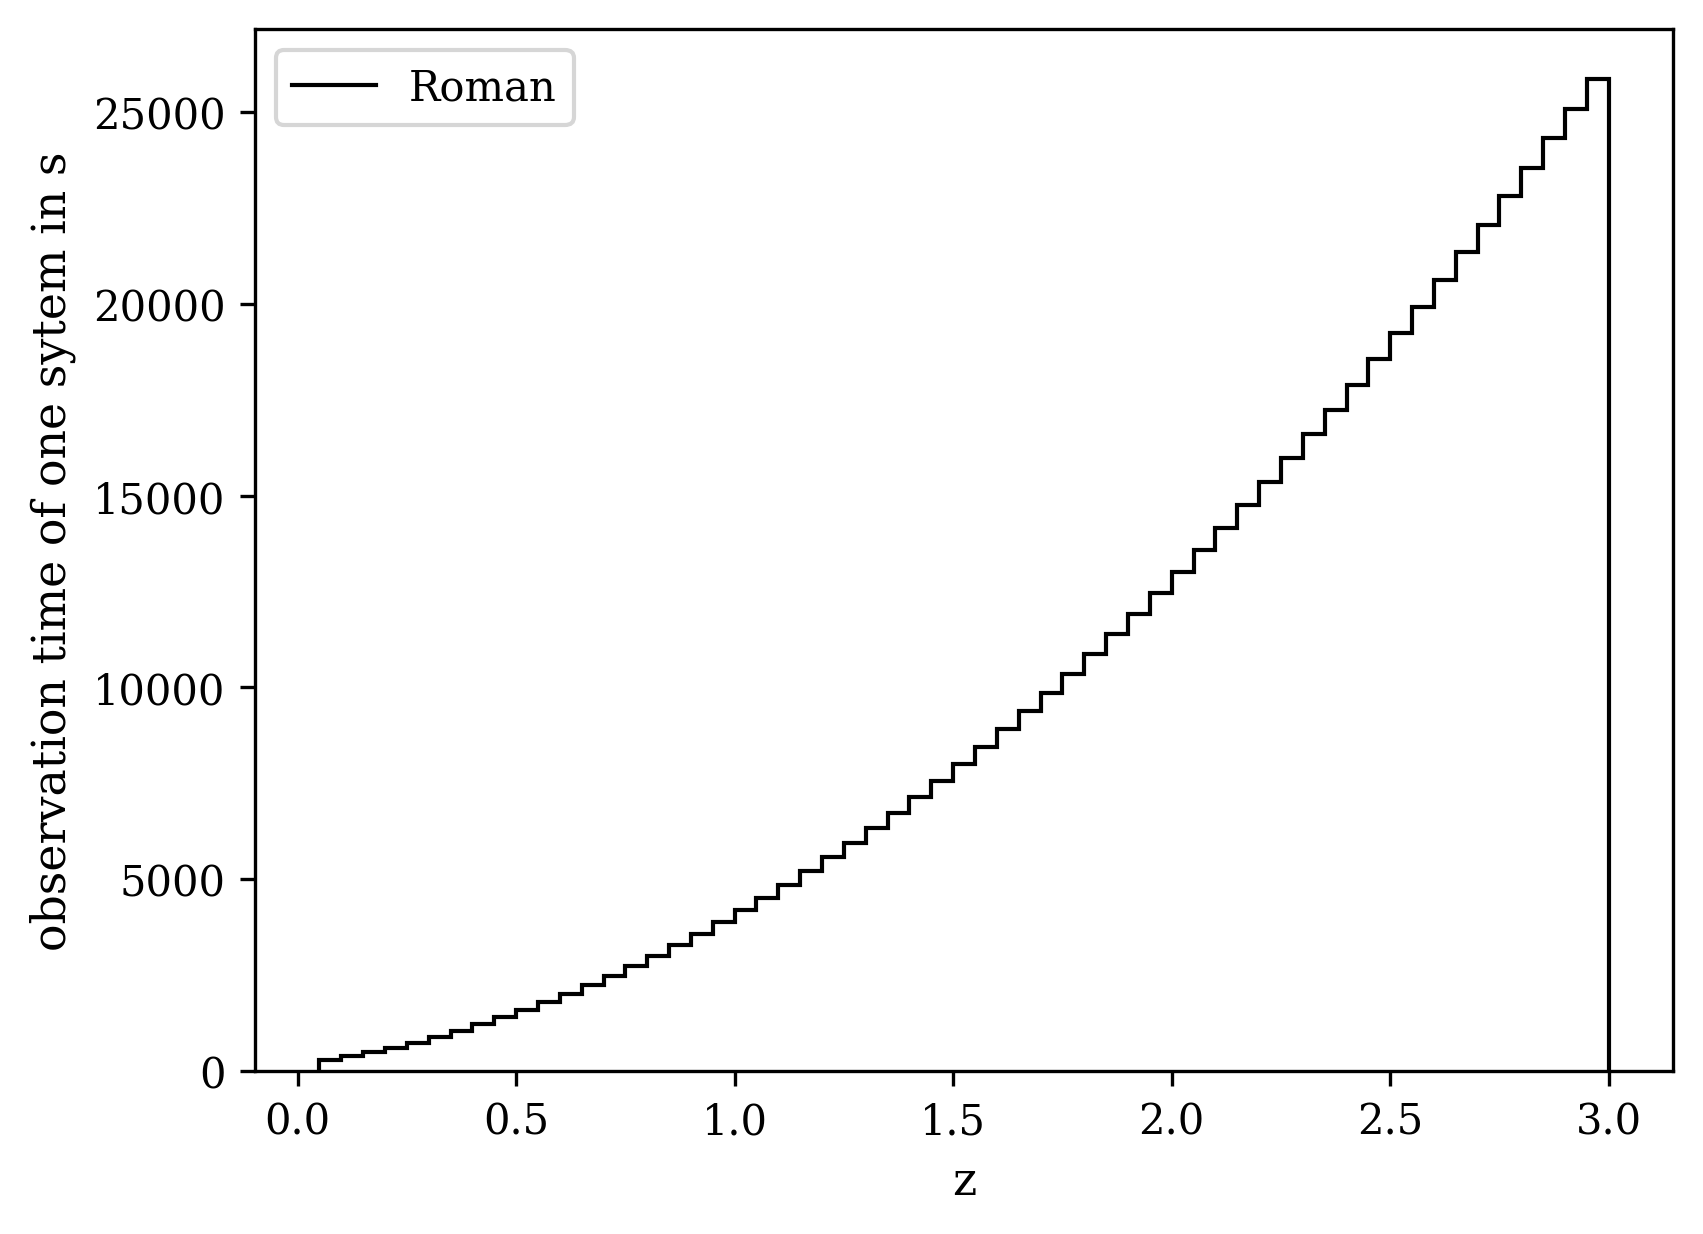

In [15]:
tt_in_hour = tt/3600


plt.stairs(tt, z_edges, label="Roman", color="black")
plt.xlabel("z")
plt.ylabel("observation time of one sytem in s")
plt.legend(loc='upper left')
##plt.savefig('figures/roman_observation_time')
plt.show()

# 2. Optimisation

In [16]:
cosmo = cosmo_fLCDM
cosmo_name = 'fLCDM'
fiducial_cosmo = fiducial_fLCDM

In [17]:
# fix H0, vary Mb
H0 = ac.WMAP9.H0

In [18]:
num_params=len(fiducial_cosmo)
h = np.full(num_params, 1e-5)

In [19]:
z_roman.shape, mb_roman.shape, Cov_roman.shape

((59,), (59,), (59, 59))

In [20]:
fiducial_cosmo, cosmo_name,

([0.3153, -19.3], 'fLCDM')

In [27]:
FF = fma.fisher_matrix_fd(fma.chi2, fiducial_cosmo, cosmo_name, H0, z_roman, mb_roman, Cov_roman,h=np.array([1e-3, 1e-3]))
FF

array([[ 43699.93392407, -22203.70133568],
       [-22203.70133568,  26616.28002784]])

In [22]:
FF = fma.fisher_matrix_observable(fiducial_cosmo, Cov_inv_roman, z_roman, cosmo_name,H0)
FF

array([[ 31395.69605074, -22203.67171167],
       [-22203.67171167,  26616.2800282 ]])

In [25]:
data_fid = fma.theory_vector(
    fiducial_cosmo,
    z_roman,
    cosmo_name,
    H0
)

print(np.max(np.abs(mb_roman - data_fid)))

0.5752308167519757


In [23]:
fma.is_positive_definite(FF)

True

In [24]:
np.linalg.eigh(FF)[0]

array([ 6674.08839214, 51337.88768681])

In [25]:
II = np.eye(FF.shape[0])
CC = np.linalg.solve(FF, II)
CC

array([[7.76814650e-05, 6.48029606e-05],
       [6.48029606e-05, 9.16305232e-05]])

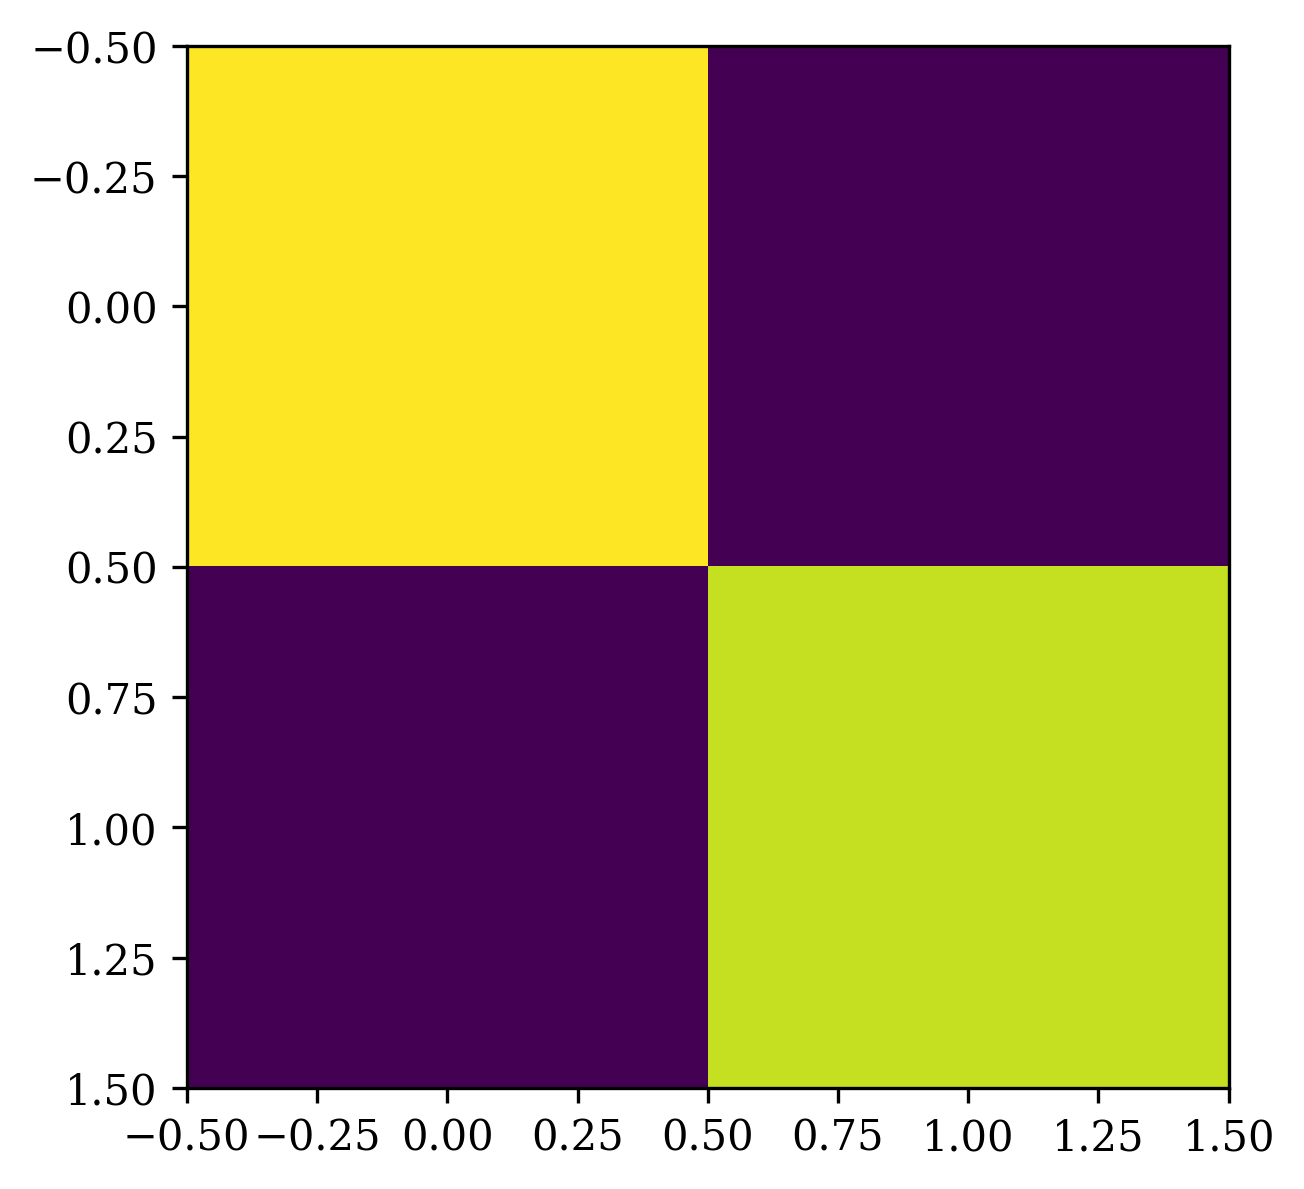

In [26]:
plt.imshow(FF)

In [27]:
fma.is_positive_definite(CC)

True

In [28]:
AA = fma.ellipse_parameters(CC, 0.32)[3] #area
FOM = 1/AA

$$
\mathrm{FoM} = \frac{1}{\pi \, \Delta\chi^2 \, \sqrt{\det \mathbf{C}}}
$$

At 68% confidence level, $\Delta\chi^2 \simeq 2.279$.

In [29]:
FOM, 1/(np.pi * sc.stats.chi2.ppf(0.68, df=2) * np.sqrt(np.linalg.det(CC)))

(2585.5076325466907, 2585.507632546691)

In [30]:
AA

0.00038677124268049956

In [31]:
T0 = (dist_roman*tt).sum()
T0

79893117.41864456

In [32]:
def generate_distribution(tt, T0, seed=None):
    rng = np.random.default_rng(seed)
    
    # 1. random positive distribution (different from dist_roman)
    n = rng.random(len(tt)) + 1e-3  # avoid zeros

    # 2. rescale to enforce total time constraint
    total_time = np.sum(n * tt)
    n *= T0 / total_time

    return n

In [33]:
# dist_roman_fake = generate_distribution(tt, T0, seed=42)
# T0_fake = (dist_roman_fake*tt).sum()
# DDf = np.diag(np.sqrt(dist_roman/dist_roman_fake))
# Cov_roman_stat_fake = DDf @ Cov_roman_stat @ DDf
# Cov_roman_fake = Cov_roman_stat_fake + Cov_roman_sys
# FF_fake = fma.fisher_matrix_fd(fma.chi2, fiducial_cosmo, cosmo_name, H0, z_roman, mb_roman, Cov_roman_fake,h=h)
# II_fake = np.eye(FF_fake.shape[0])
# CC_fake = np.linalg.solve(FF_fake, II_fake)
# AA_fake = fma.ellipse_parameters(CC_fake, 0.32)[3] #area
# FOM_fake = 1/AA_fake
# print(T0_fake)

# # plot
# plt.stairs(dist_roman_fake, z_edges, label="False Roman data distribution", color="black")
# plt.xlabel("z",size=15)
# plt.ylabel("SNIa count")
# plt.legend(loc='upper right')
# plt.show()

In [34]:
# fma.is_positive_definite(Cov_roman_stat_fake)

In [59]:
nb_iter=1000
perturbation=1

results = opt.optimize_bins_gen(
    nb_iter=nb_iter,
    perturbation=perturbation,
    dist_roman=dist_roman,
    Cov_roman=Cov_roman,
    Cov_roman_stat=Cov_roman_stat,
    Cov_roman_sys=Cov_roman_sys,
    FOM=FOM,
    H0=H0,
    z_roman=z_roman,
    tt=tt,
    fiducial_cosmo=fiducial_fLCDM,
    cosmo_name=cosmo_name,
    use_marginalization=False,
    verbose=False
)

optimized_dist       = results["optimized_dist"]

track_distribution   = results["track_distribution"]
track_delta_n        = results["track_delta_n"]
track_Cov            = results["track_Cov"]
track_dFOM           = results["track_dFOM"]
track_dFOM_triche    = results["track_dFOM_triche"]
track_kk             = results["track_kk"]
track_FF             = results["track_FF"]
track_ellipse        = results["track_ellipse"]


Optimizing bins:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
save_as = "results/optimization_tracks_roman_1000.npz"
np.savez_compressed(
    save_as,
    track_ellipse = track_ellipse,
    track_FF = track_FF,
    track_distribution = track_distribution,
    track_delta_n = track_delta_n,
    track_Cov = track_Cov,
    track_dFOM = track_dFOM,
    track_dFOM_triche = track_dFOM_triche,
    track_kk = track_kk,
)

print("All tracking arrays saved to", save_as)

All tracking arrays saved to optimization_tracks_roman_1000.npz


In [ ]:
track_data = np.load("results/optimization_tracks_roman_1000.npz")

track_ellipse = track_data["track_ellipse"]
track_FF = track_data["track_FF"]
track_distribution = track_data["track_distribution"]
track_delta_n = track_data["track_delta_n"]
track_Cov = track_data["track_Cov"]
track_dFOM = track_data["track_dFOM"]
track_dFOM_triche = track_data["track_dFOM_triche"]
track_kk = track_data["track_kk"]
optimized_dist = track_distribution[-1]

print("All tracking arrays successfully loaded")

All tracking arrays successfully loaded


In [62]:
obs_time_opt = (optimized_dist*tt).sum()
print('Original observation time:', obs_time_roman)
print('Observation time after optimization', obs_time_opt)
print('Observation time ratio:', obs_time_opt/obs_time_roman)

Original observation time: 79893117.41864456
Observation time after optimization 79893117.41864455
Observation time ratio: 0.9999999999999998


In [63]:
print('area ratio new/ref', track_ellipse[-1][3]/AA)

area ratio new/ref 0.7434736864665792


Text(0, 0.5, 'cosmological leverage')

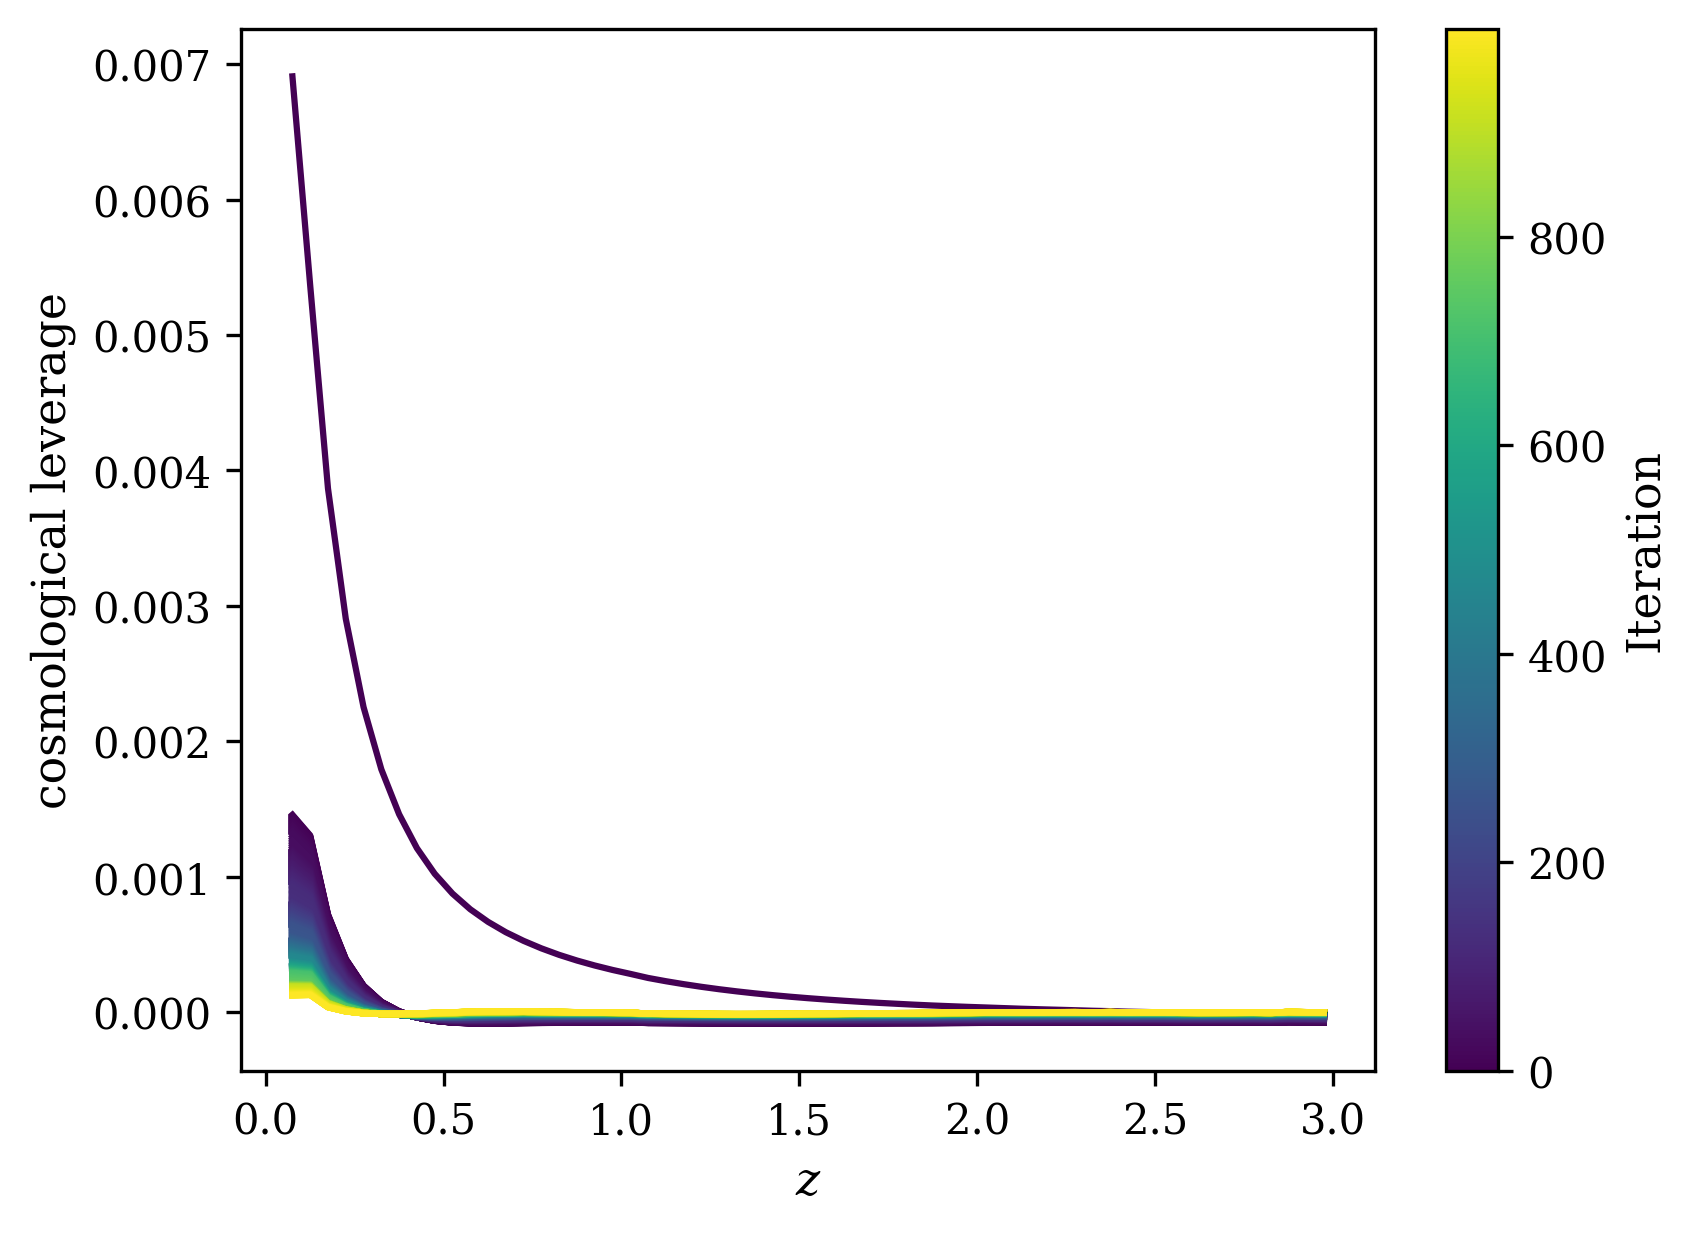

In [64]:
cmap = plt.cm.viridis  # choose any colormap you like
norm = plt.Normalize(vmin=0, vmax=nb_iter-1)

for ii in range(track_Cov.shape[0]):
    plt.plot(z_roman, track_dFOM[ii],
                color=cmap(norm(ii)))

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             label='Iteration')

plt.xlabel(r'$z$')
plt.ylabel('cosmological leverage')

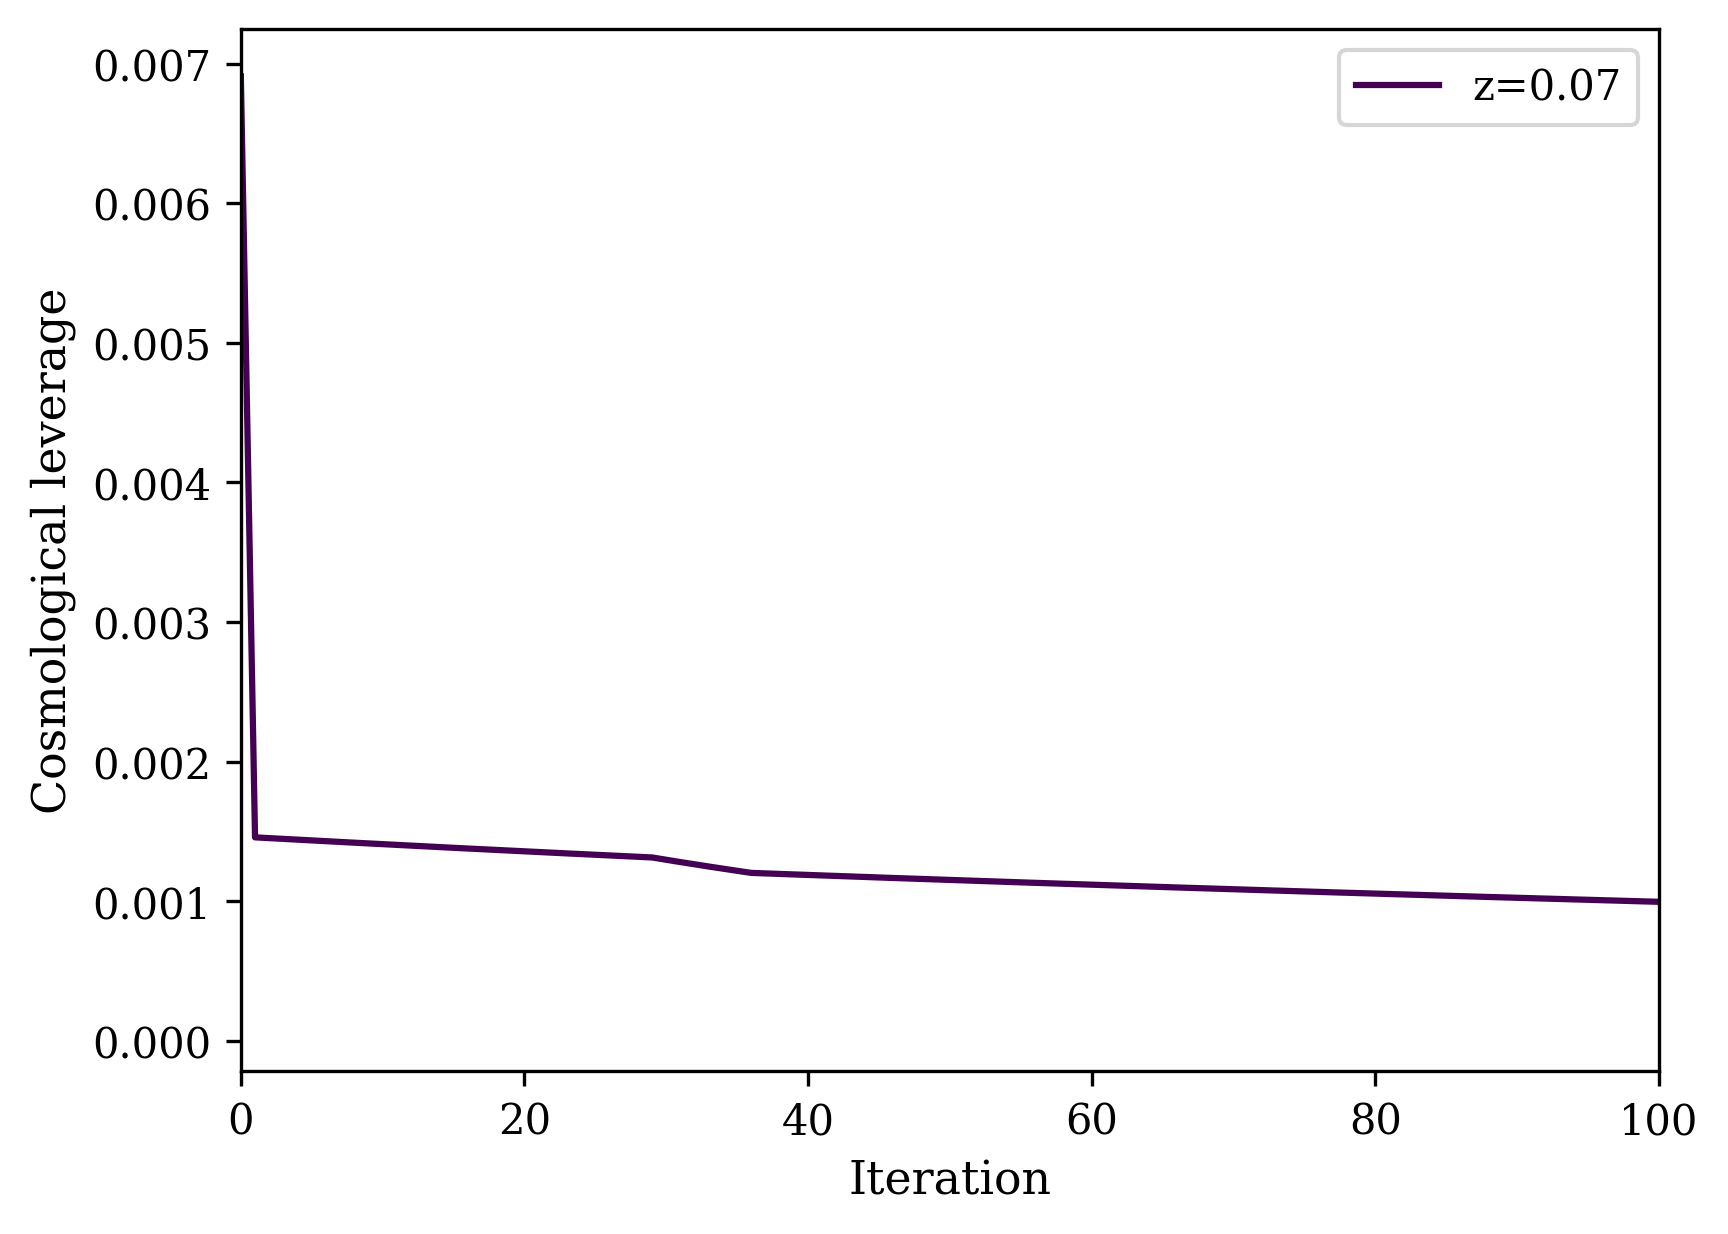

In [65]:
cmap = plt.cm.viridis
z_indices = [0]  # choose a few z points

norm = plt.Normalize(vmin=min(z_indices), vmax=max(z_indices))

iterations = np.arange(track_dFOM.shape[0])

for zi in z_indices:
    plt.plot(iterations, track_dFOM[:, zi],
             color=cmap(norm(zi)),
             label=f'z={z_roman[zi]:.2f}')
plt.xlim(0,100)
plt.xlabel('Iteration')
plt.ylabel('Cosmological leverage')
plt.legend()

Text(0, 0.5, 'cosmological leverage')

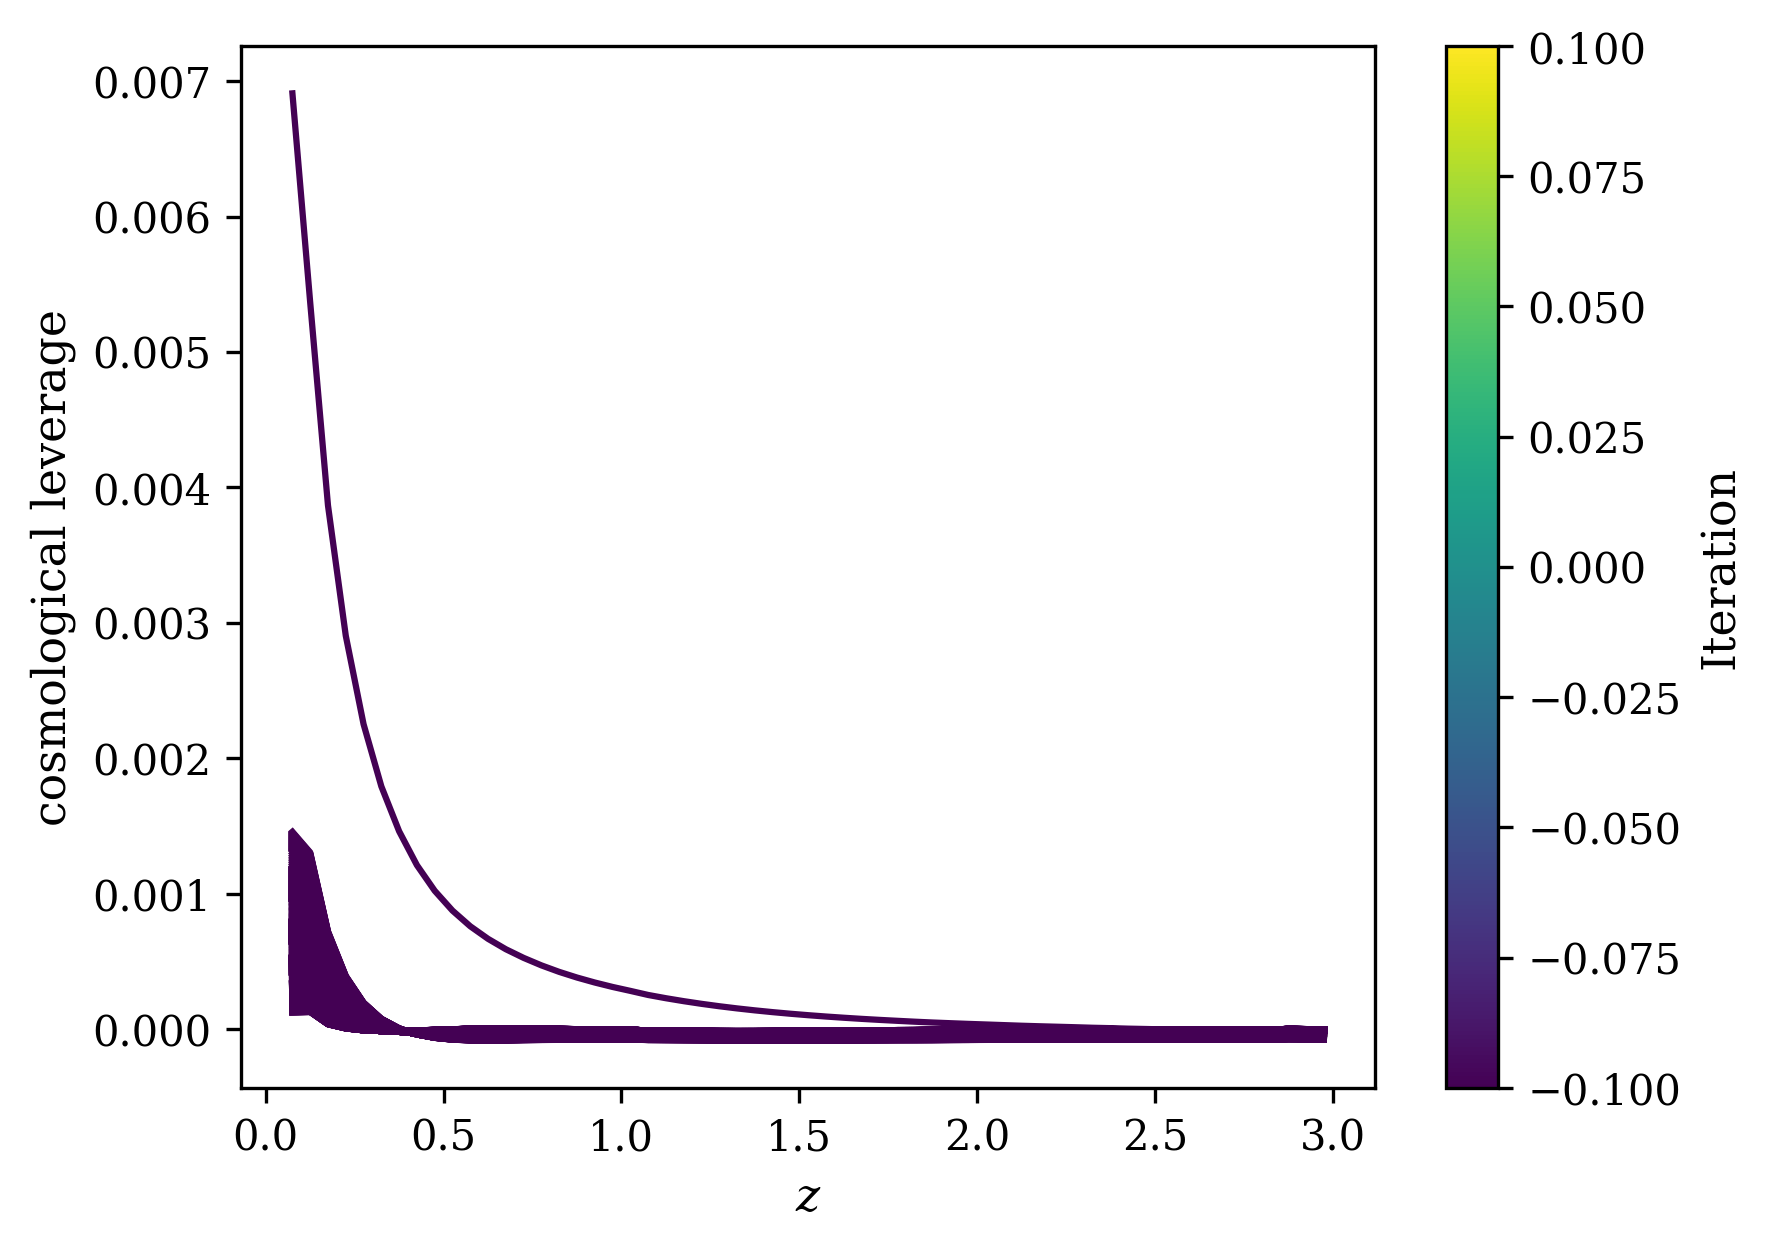

In [66]:


for ii in range(track_Cov.shape[0]):
    plt.plot(z_roman, track_dFOM[ii],
                color=cmap(norm(ii)))

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             label='Iteration')

plt.xlabel(r'$z$')
plt.ylabel('cosmological leverage')

In [67]:
dist_roman

array([811,  24,  53,  79, 106, 146, 189, 233, 266, 313, 375, 424, 471,
       539, 563, 608, 629, 660, 700, 670, 654, 659, 650, 612, 556, 516,
       504, 436, 409, 374, 331, 289, 270, 223, 175, 161, 151, 132, 110,
        90,  78,  82,  69,  51,  59,  45,  44,  32,  22,  20,  11,  10,
        11,   9,   8,   4,   3,   3,   4], dtype=int64)

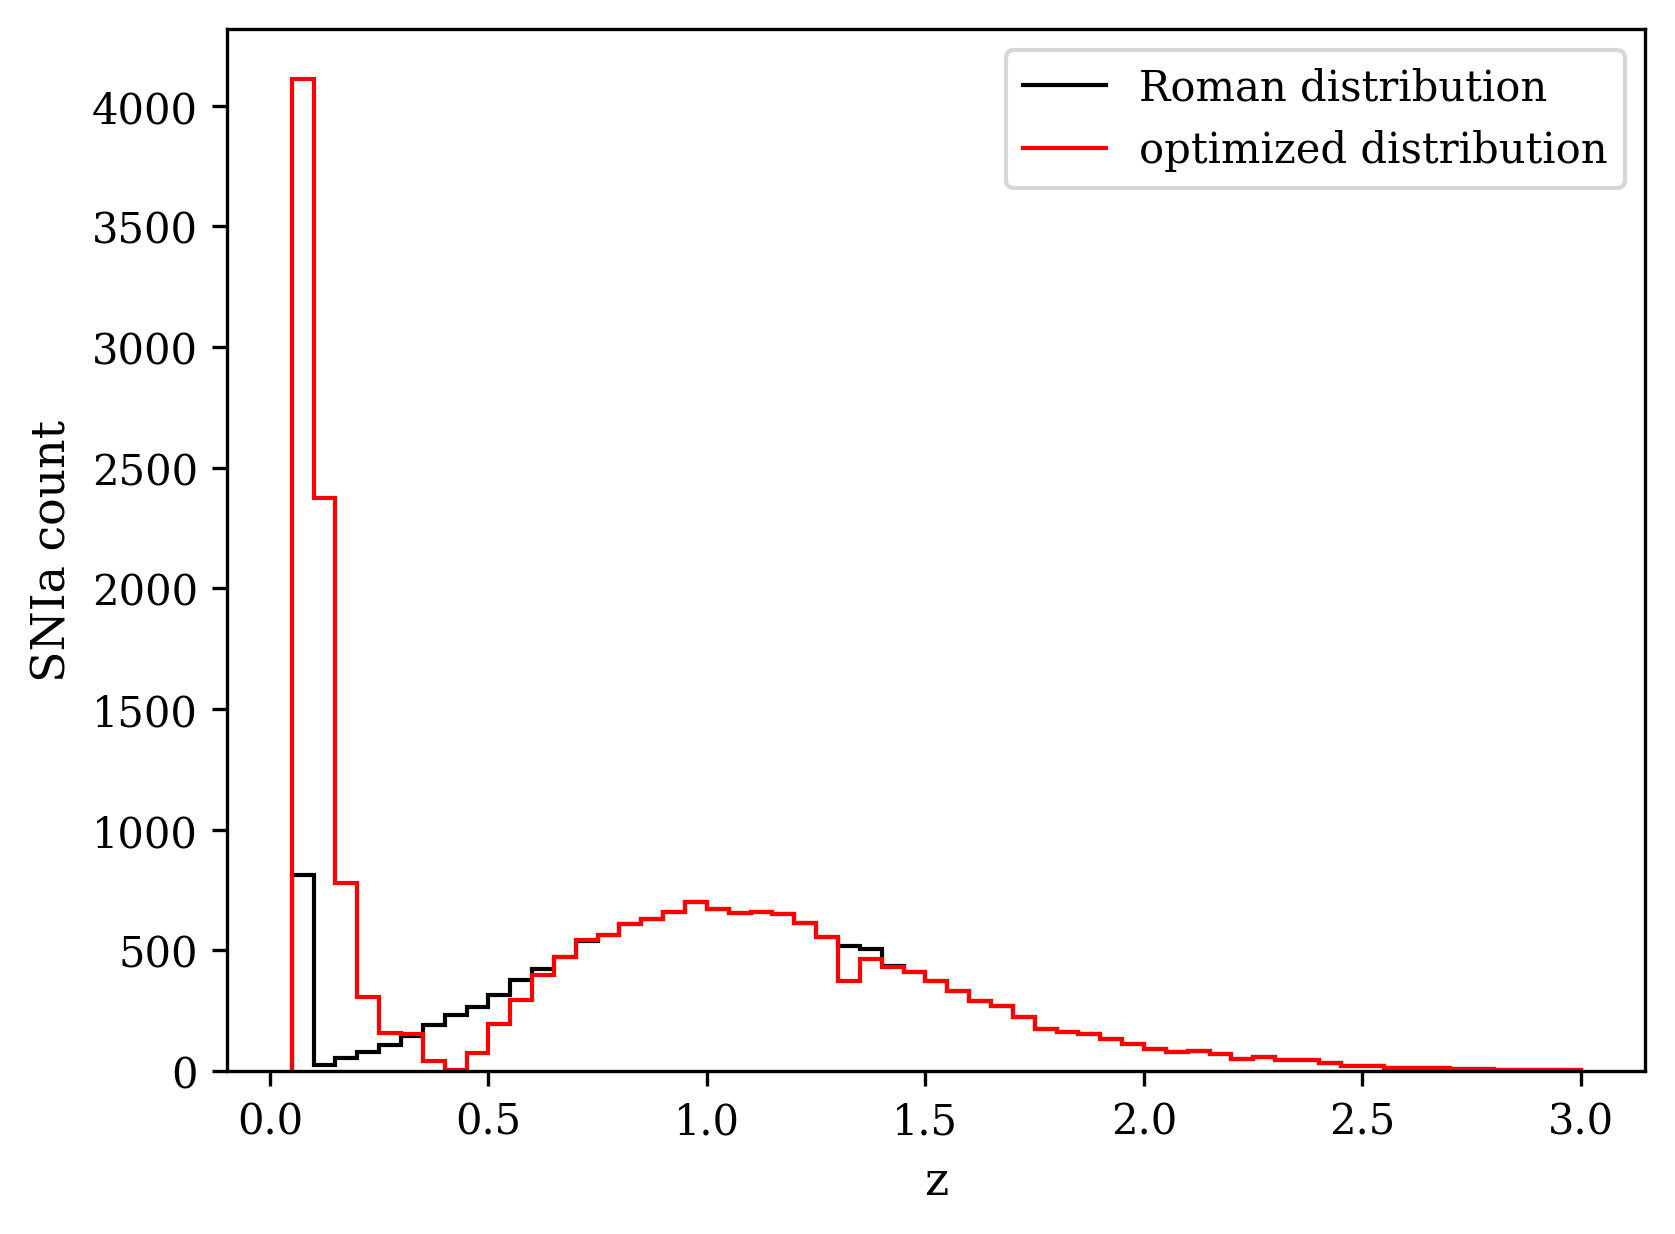

In [68]:
# plot
plt.stairs(dist_roman, z_edges, label="Roman distribution", color="black")
#plt.stairs(dist_roman_fake, z_edges, label="Roman fake distribution", color="black")
plt.stairs(track_distribution[-1], z_edges, label='optimized distribution', color='red')
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
#plt.savefig('figures/dist_comparison_roman_100')
plt.show()

Text(0, 0.5, 'area')

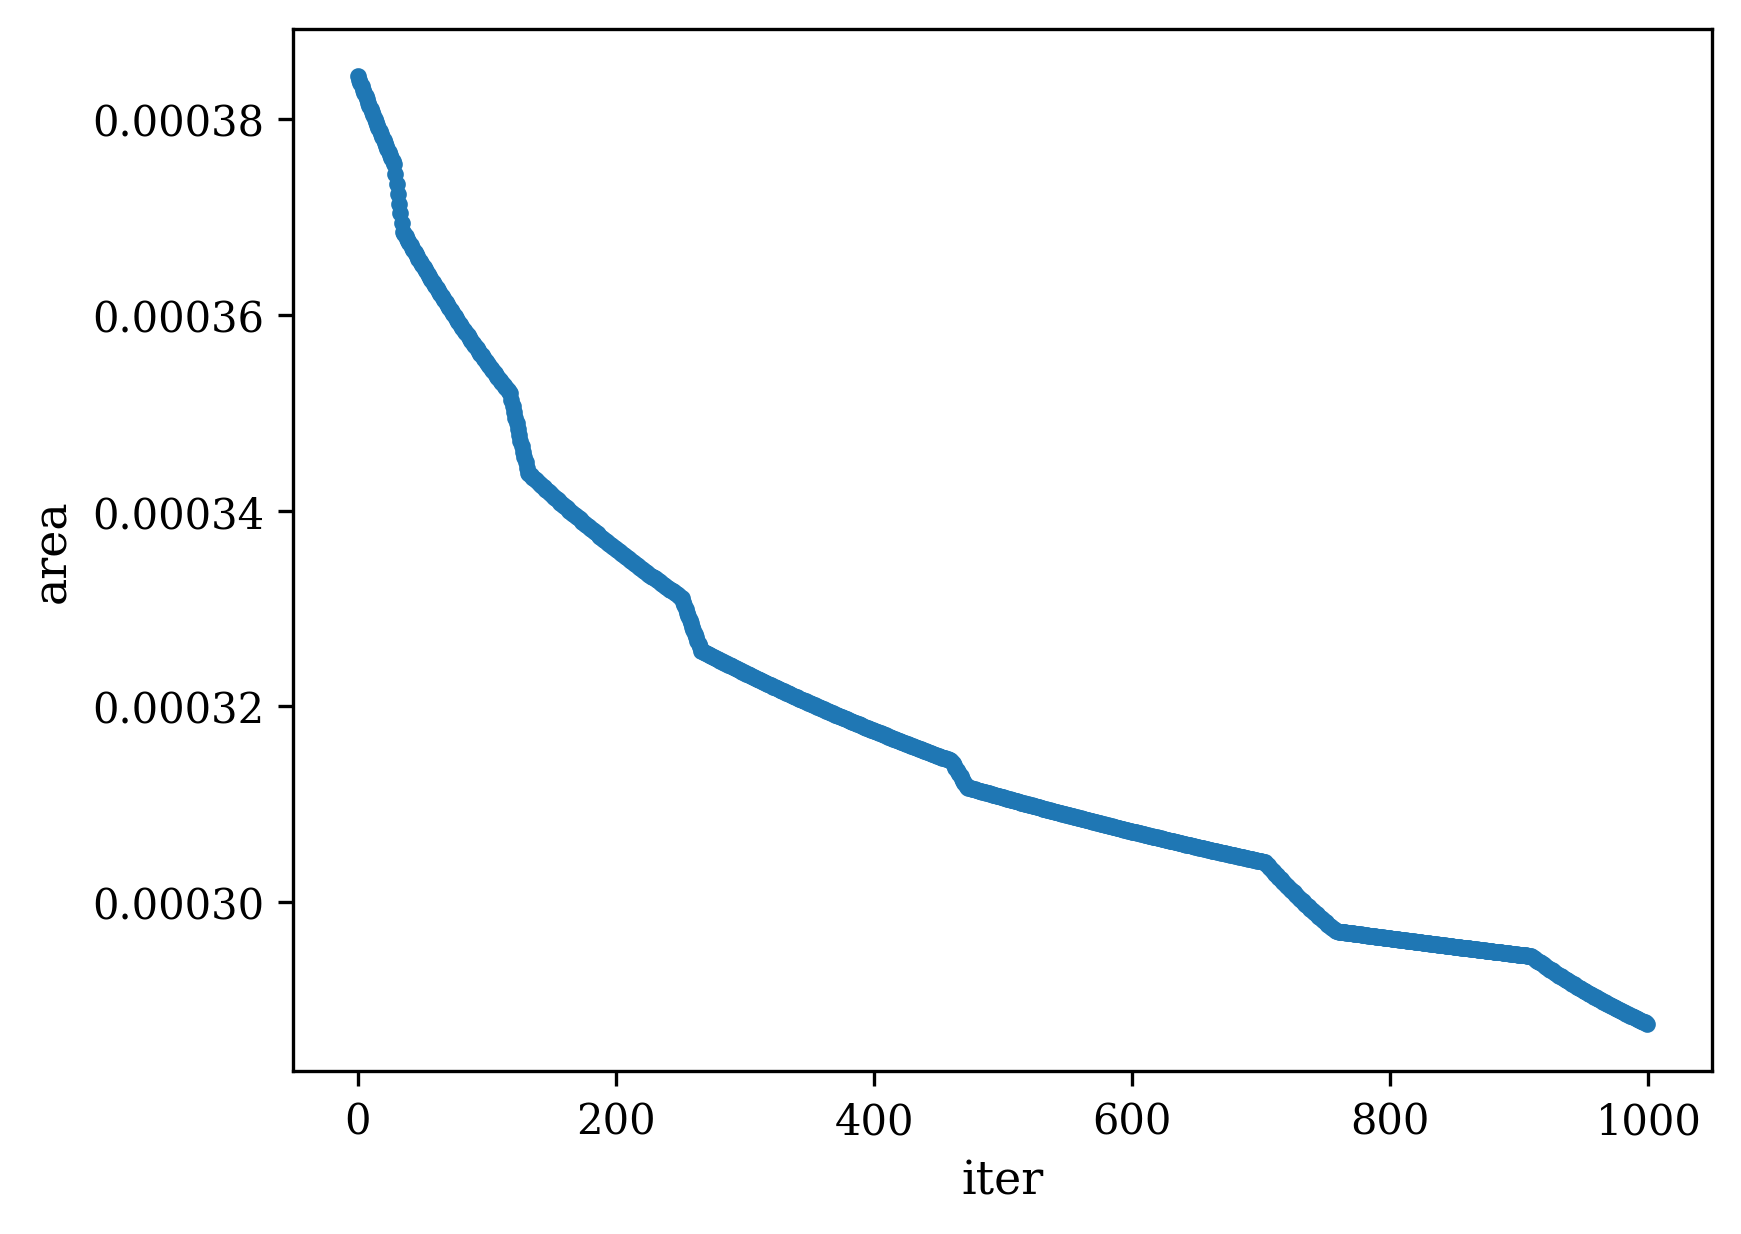

In [69]:
plt.plot(track_ellipse[:,3], marker='.')
plt.xlabel('iter')
plt.ylabel('area')
#plt.savefig('figures/track_area_roman_100')

Text(0, 0.5, 'FOM')

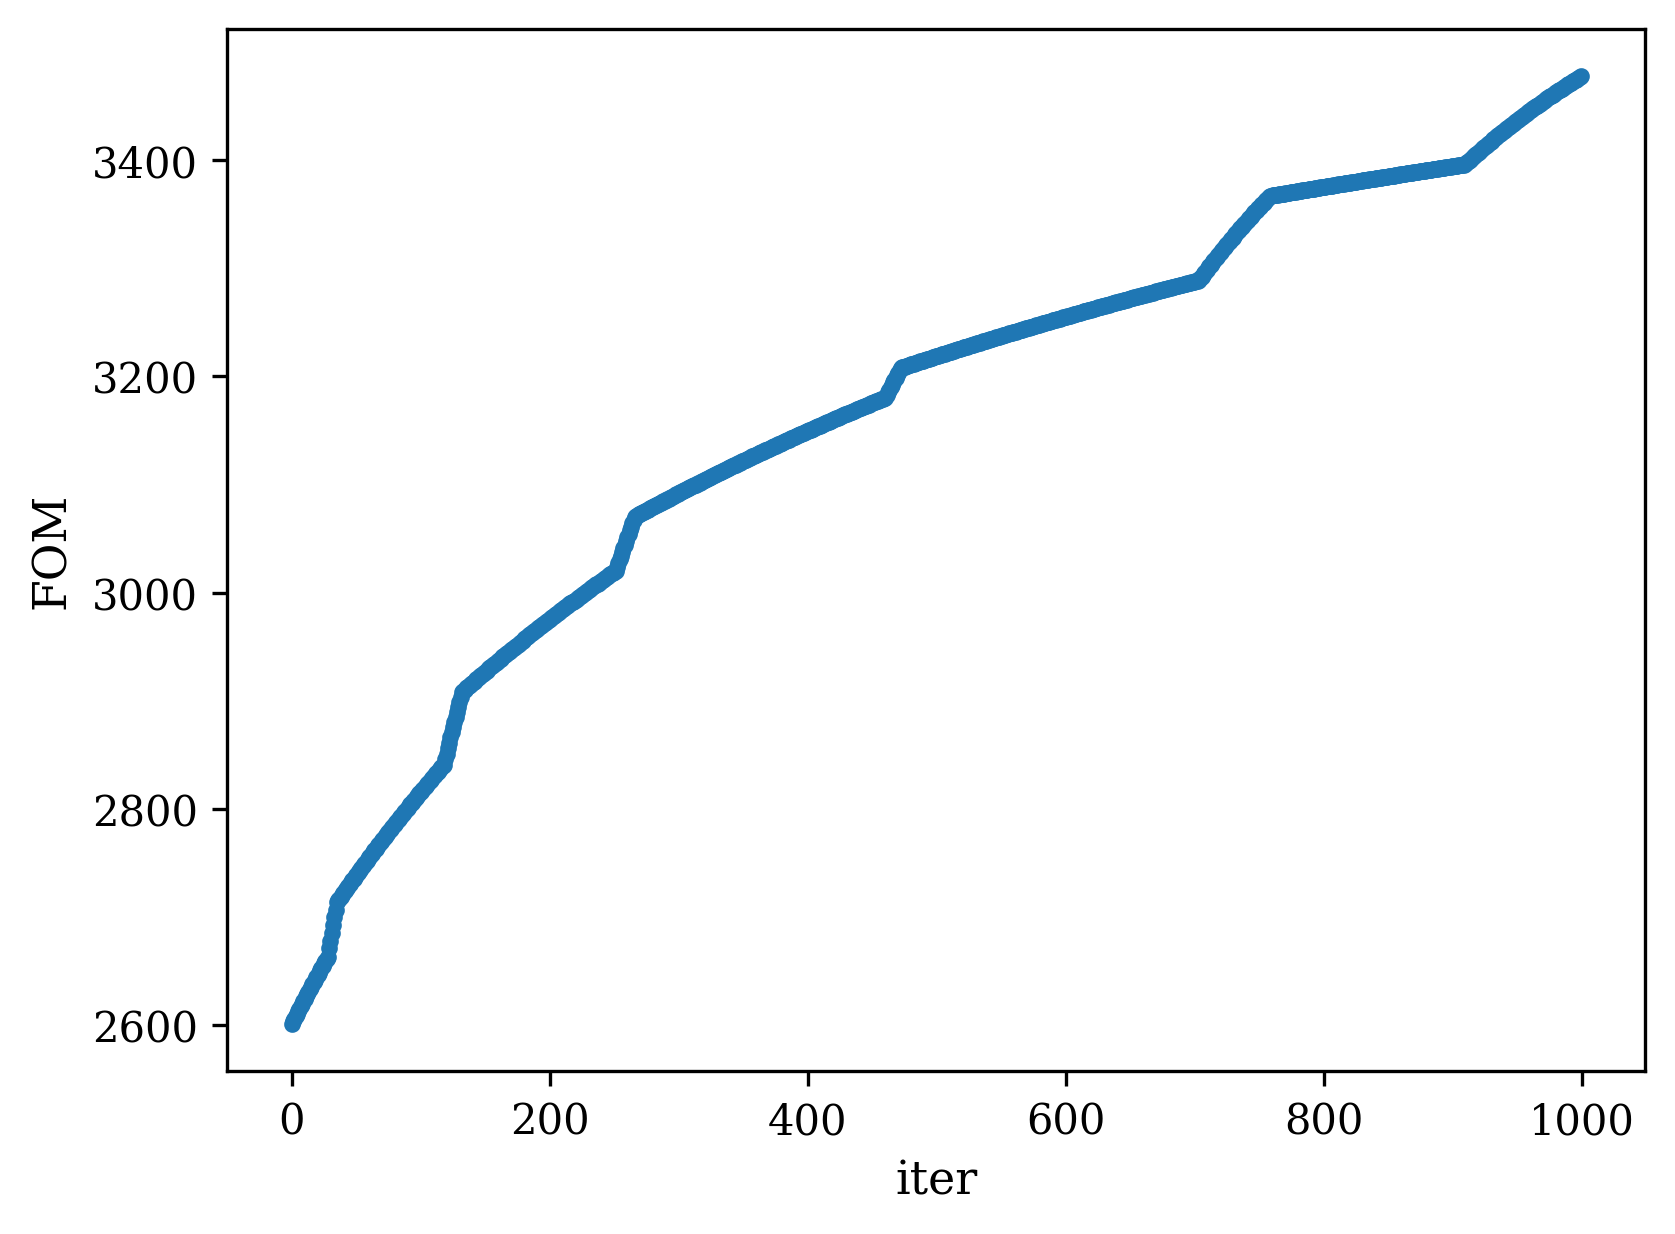

In [70]:
plt.plot(1/track_ellipse[:,3], marker='.')
plt.xlabel('iter')
plt.ylabel('FOM')
#plt.savefig('figures/track_fom_roman_100')

In [71]:
len(track_kk)

1000

Text(0, 0.5, 'iter')

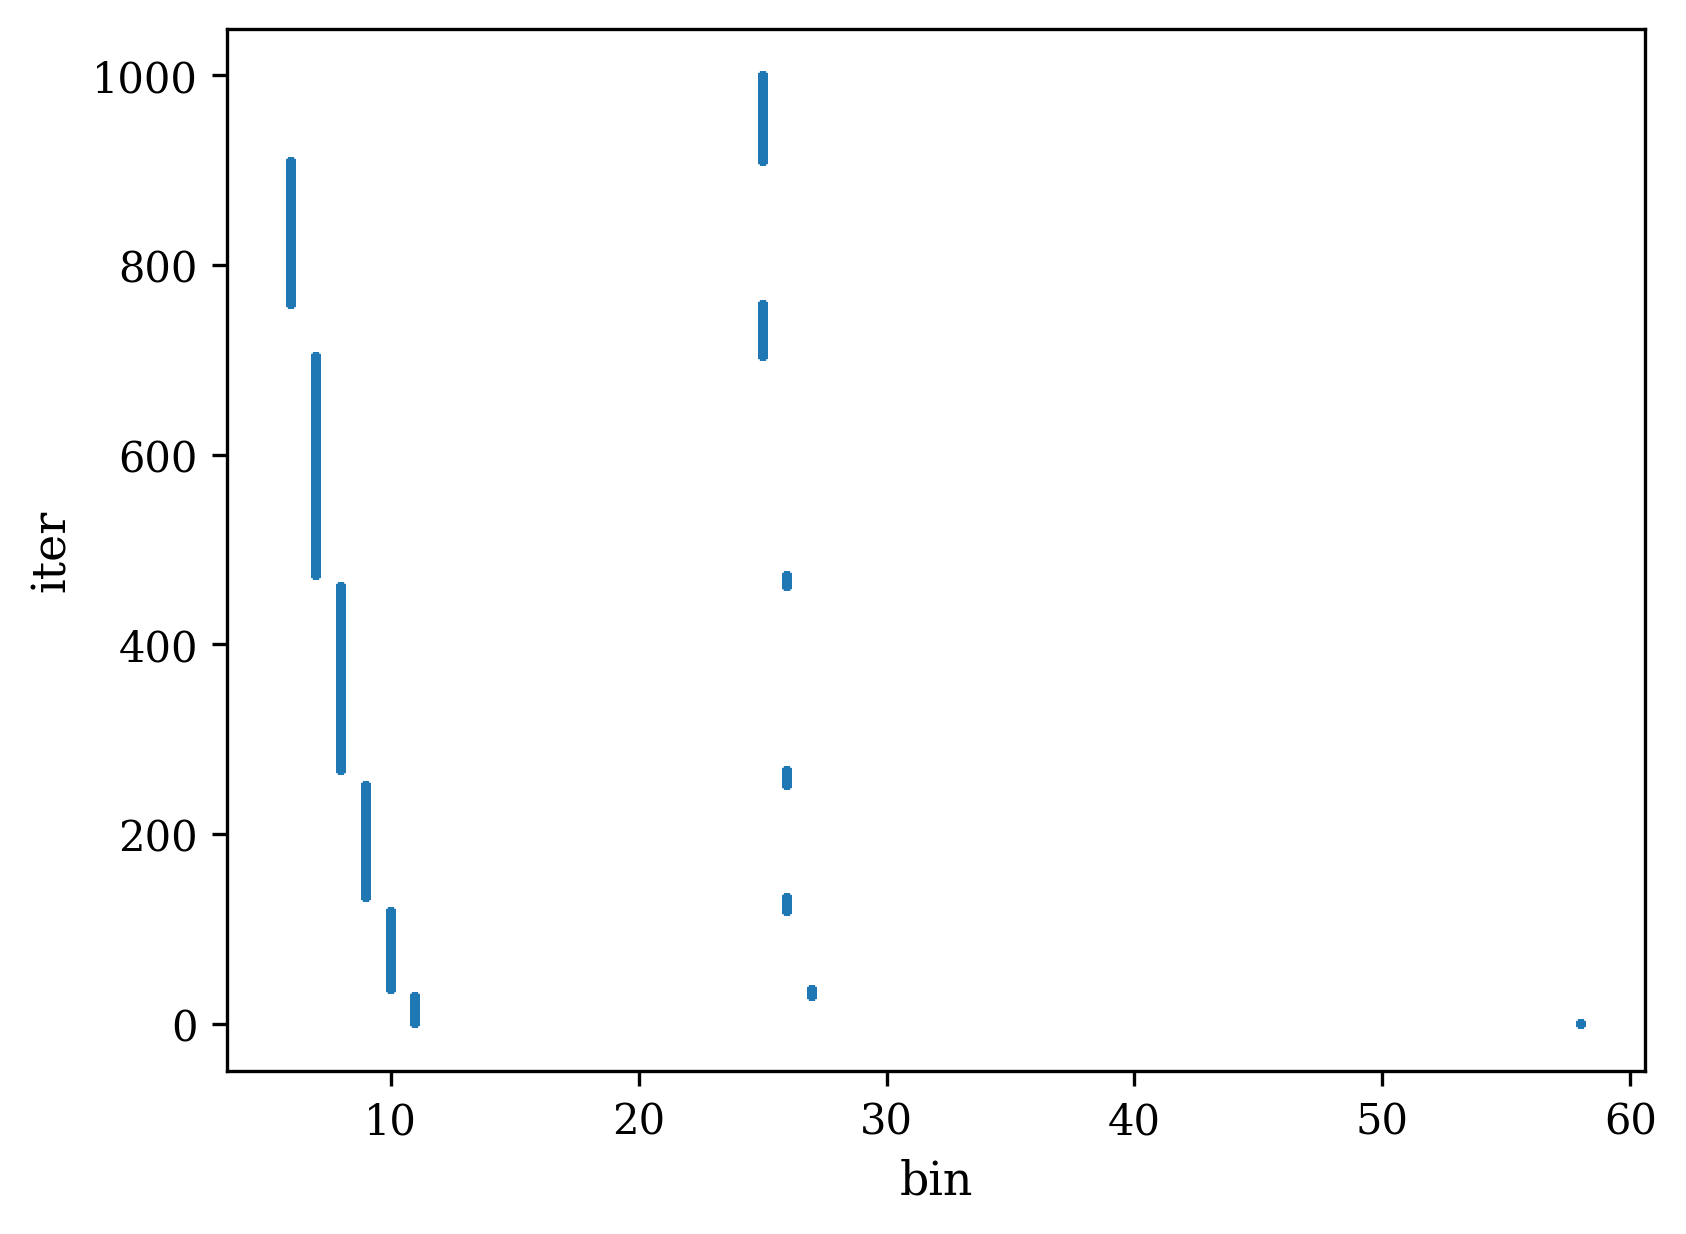

In [72]:
plt.scatter(track_kk,np.arange(0,len(track_kk),1),s=5,marker='+')
plt.xlabel('bin')
plt.ylabel('iter')

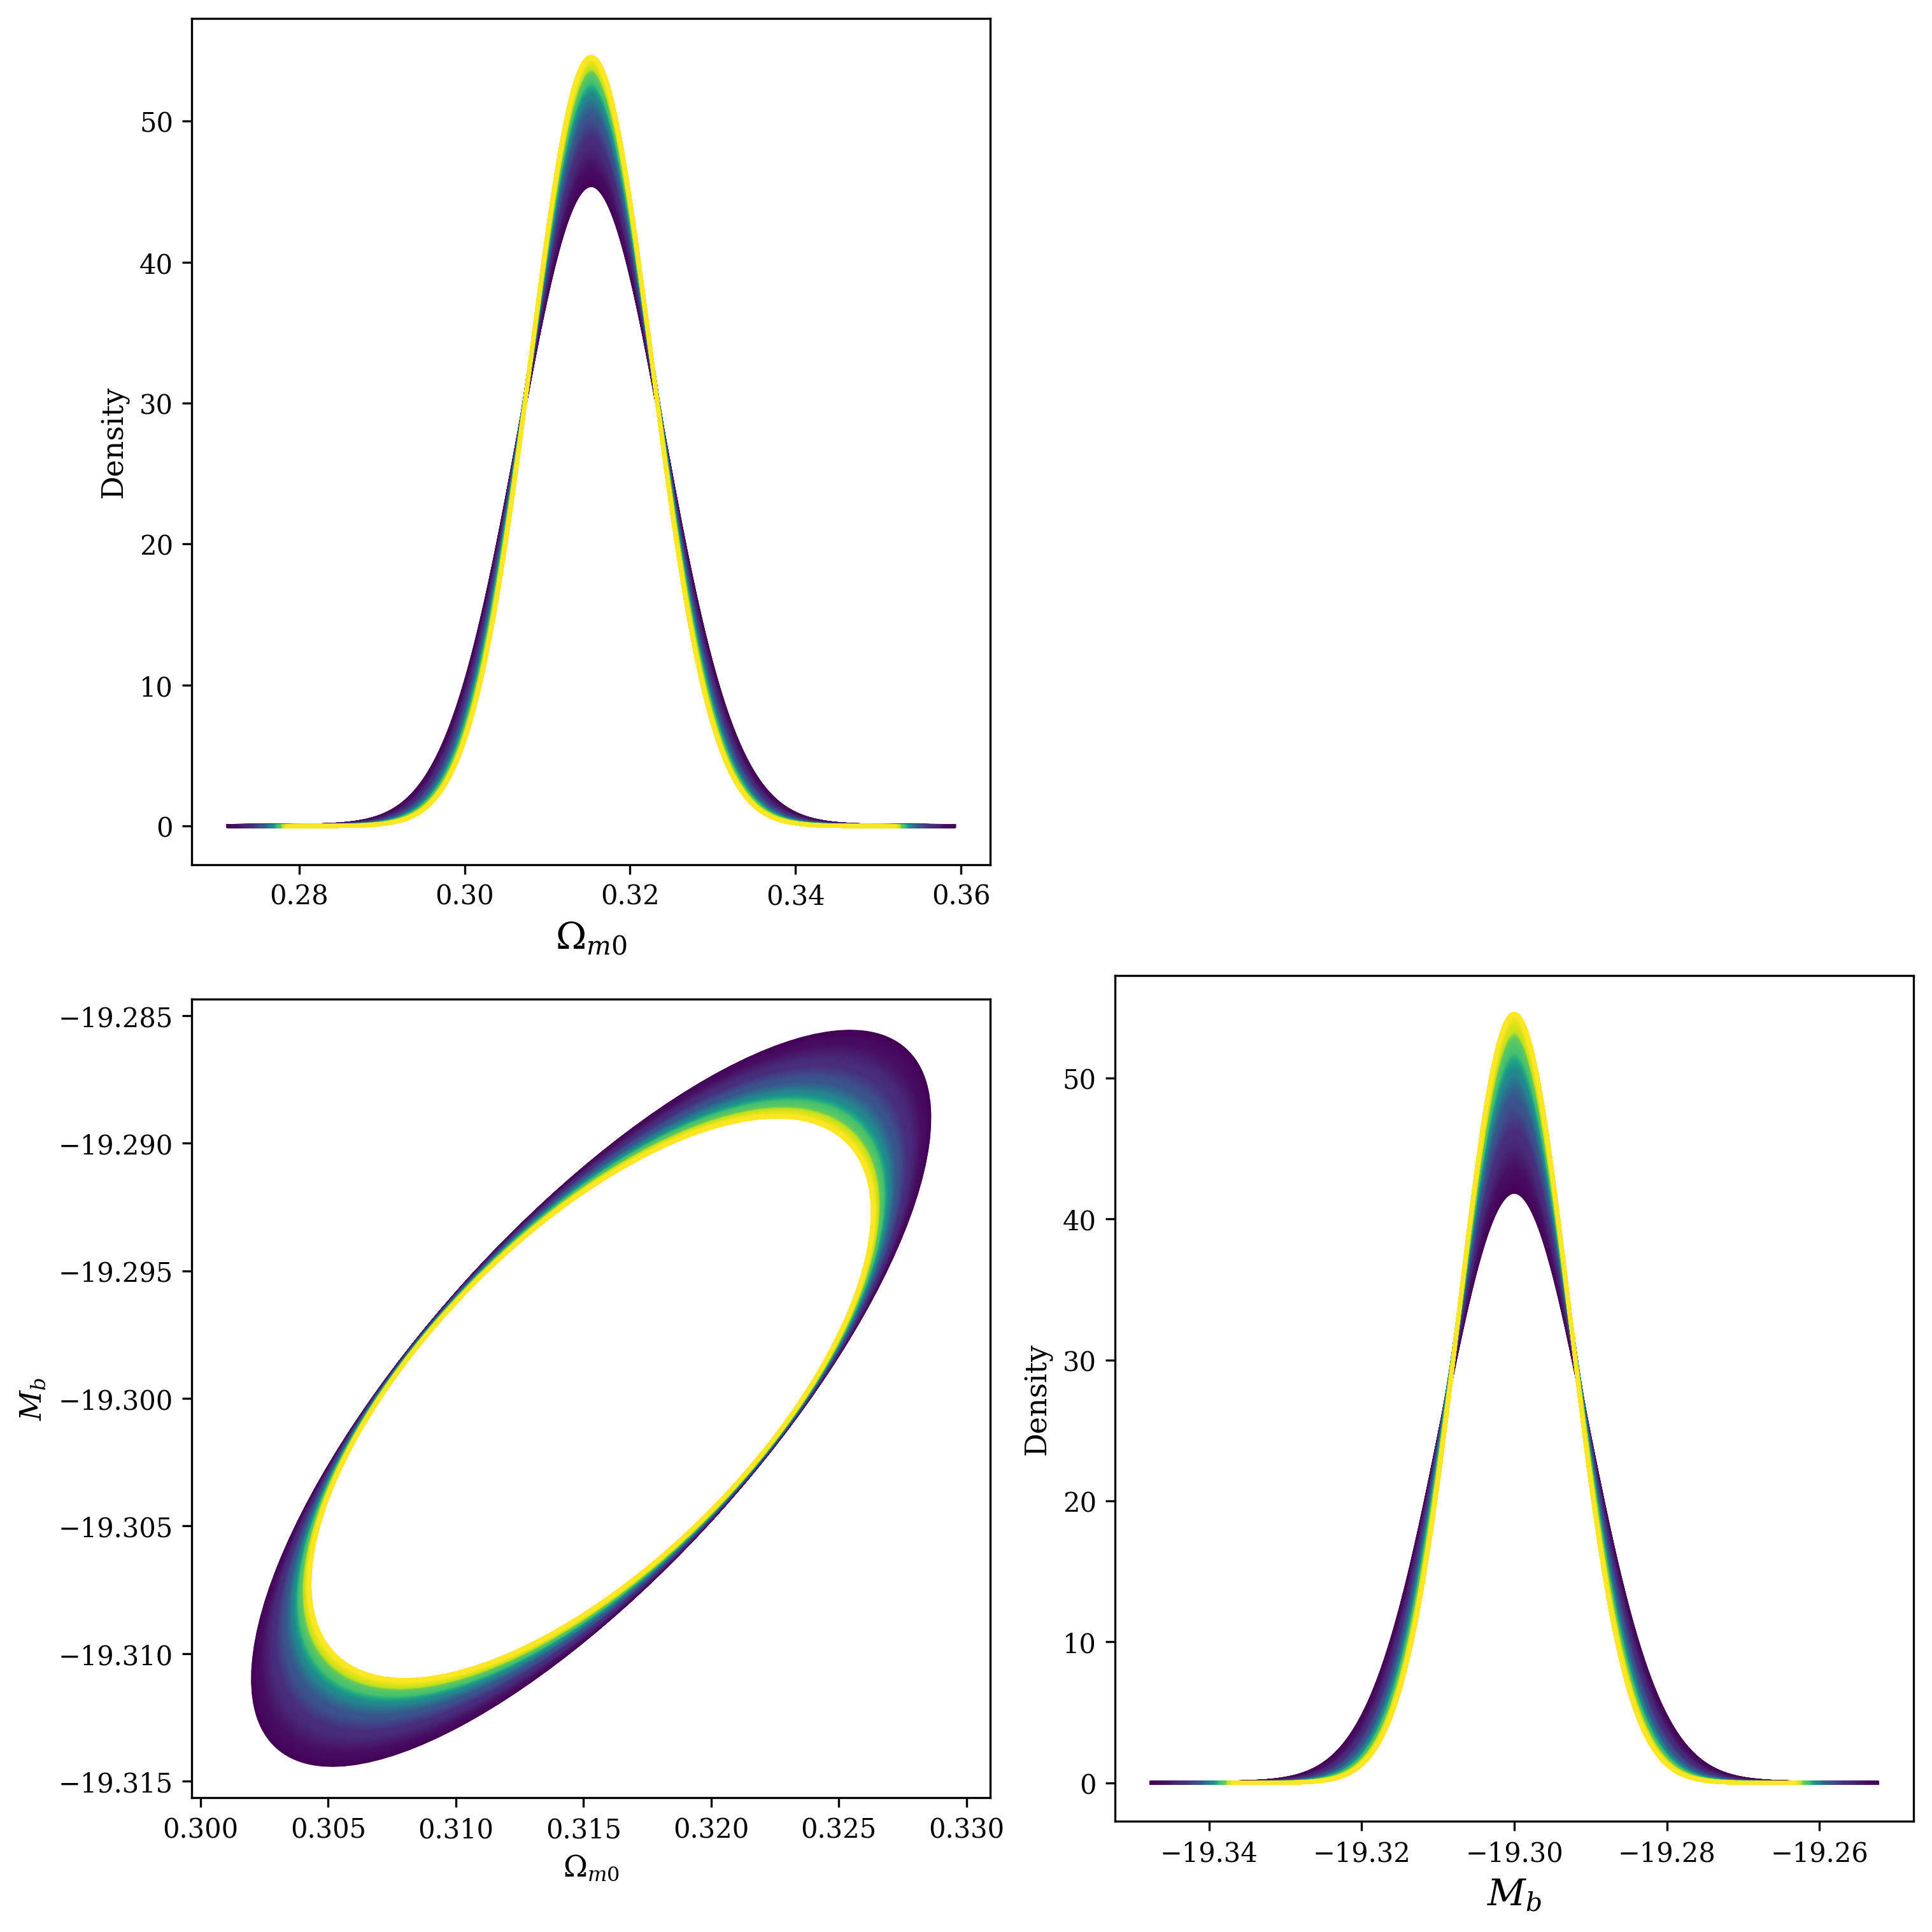

In [73]:
param_names = ['Om0', 'Mb']
param_labels = [r'$\Omega_{m0}$', r'$M_b$']
param_to_plot = ['Om0',  'Mb']
fiducial_param = [Om0_fLCDM, Mb_fid]

N = len(track_FF)  
cmap = cm.viridis  
clrs = cmap(np.linspace(0, 1, N))

fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)

for i, fisher_matrix in enumerate(track_FF):
    color = clrs[i]
    fma.add_fisher_to_plot(
        fisher_matrix,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color=color,
        filled=False,
        param_labels=param_labels
    )


# fma.add_fisher_to_plot(
#         FF,
#         fiducial_param=[w0_fCPL, wa_fCPL],
#         axs_2d=axs_2d,
#         axs_1d=axs_1d,
#         param_indices=param_indices,
#         alpha_values=[0.32],
#         color='blue',
#         filled=False,
#         param_labels=param_labels
#     )

# plt.savefig('figures/track_ellipses_roman_100')

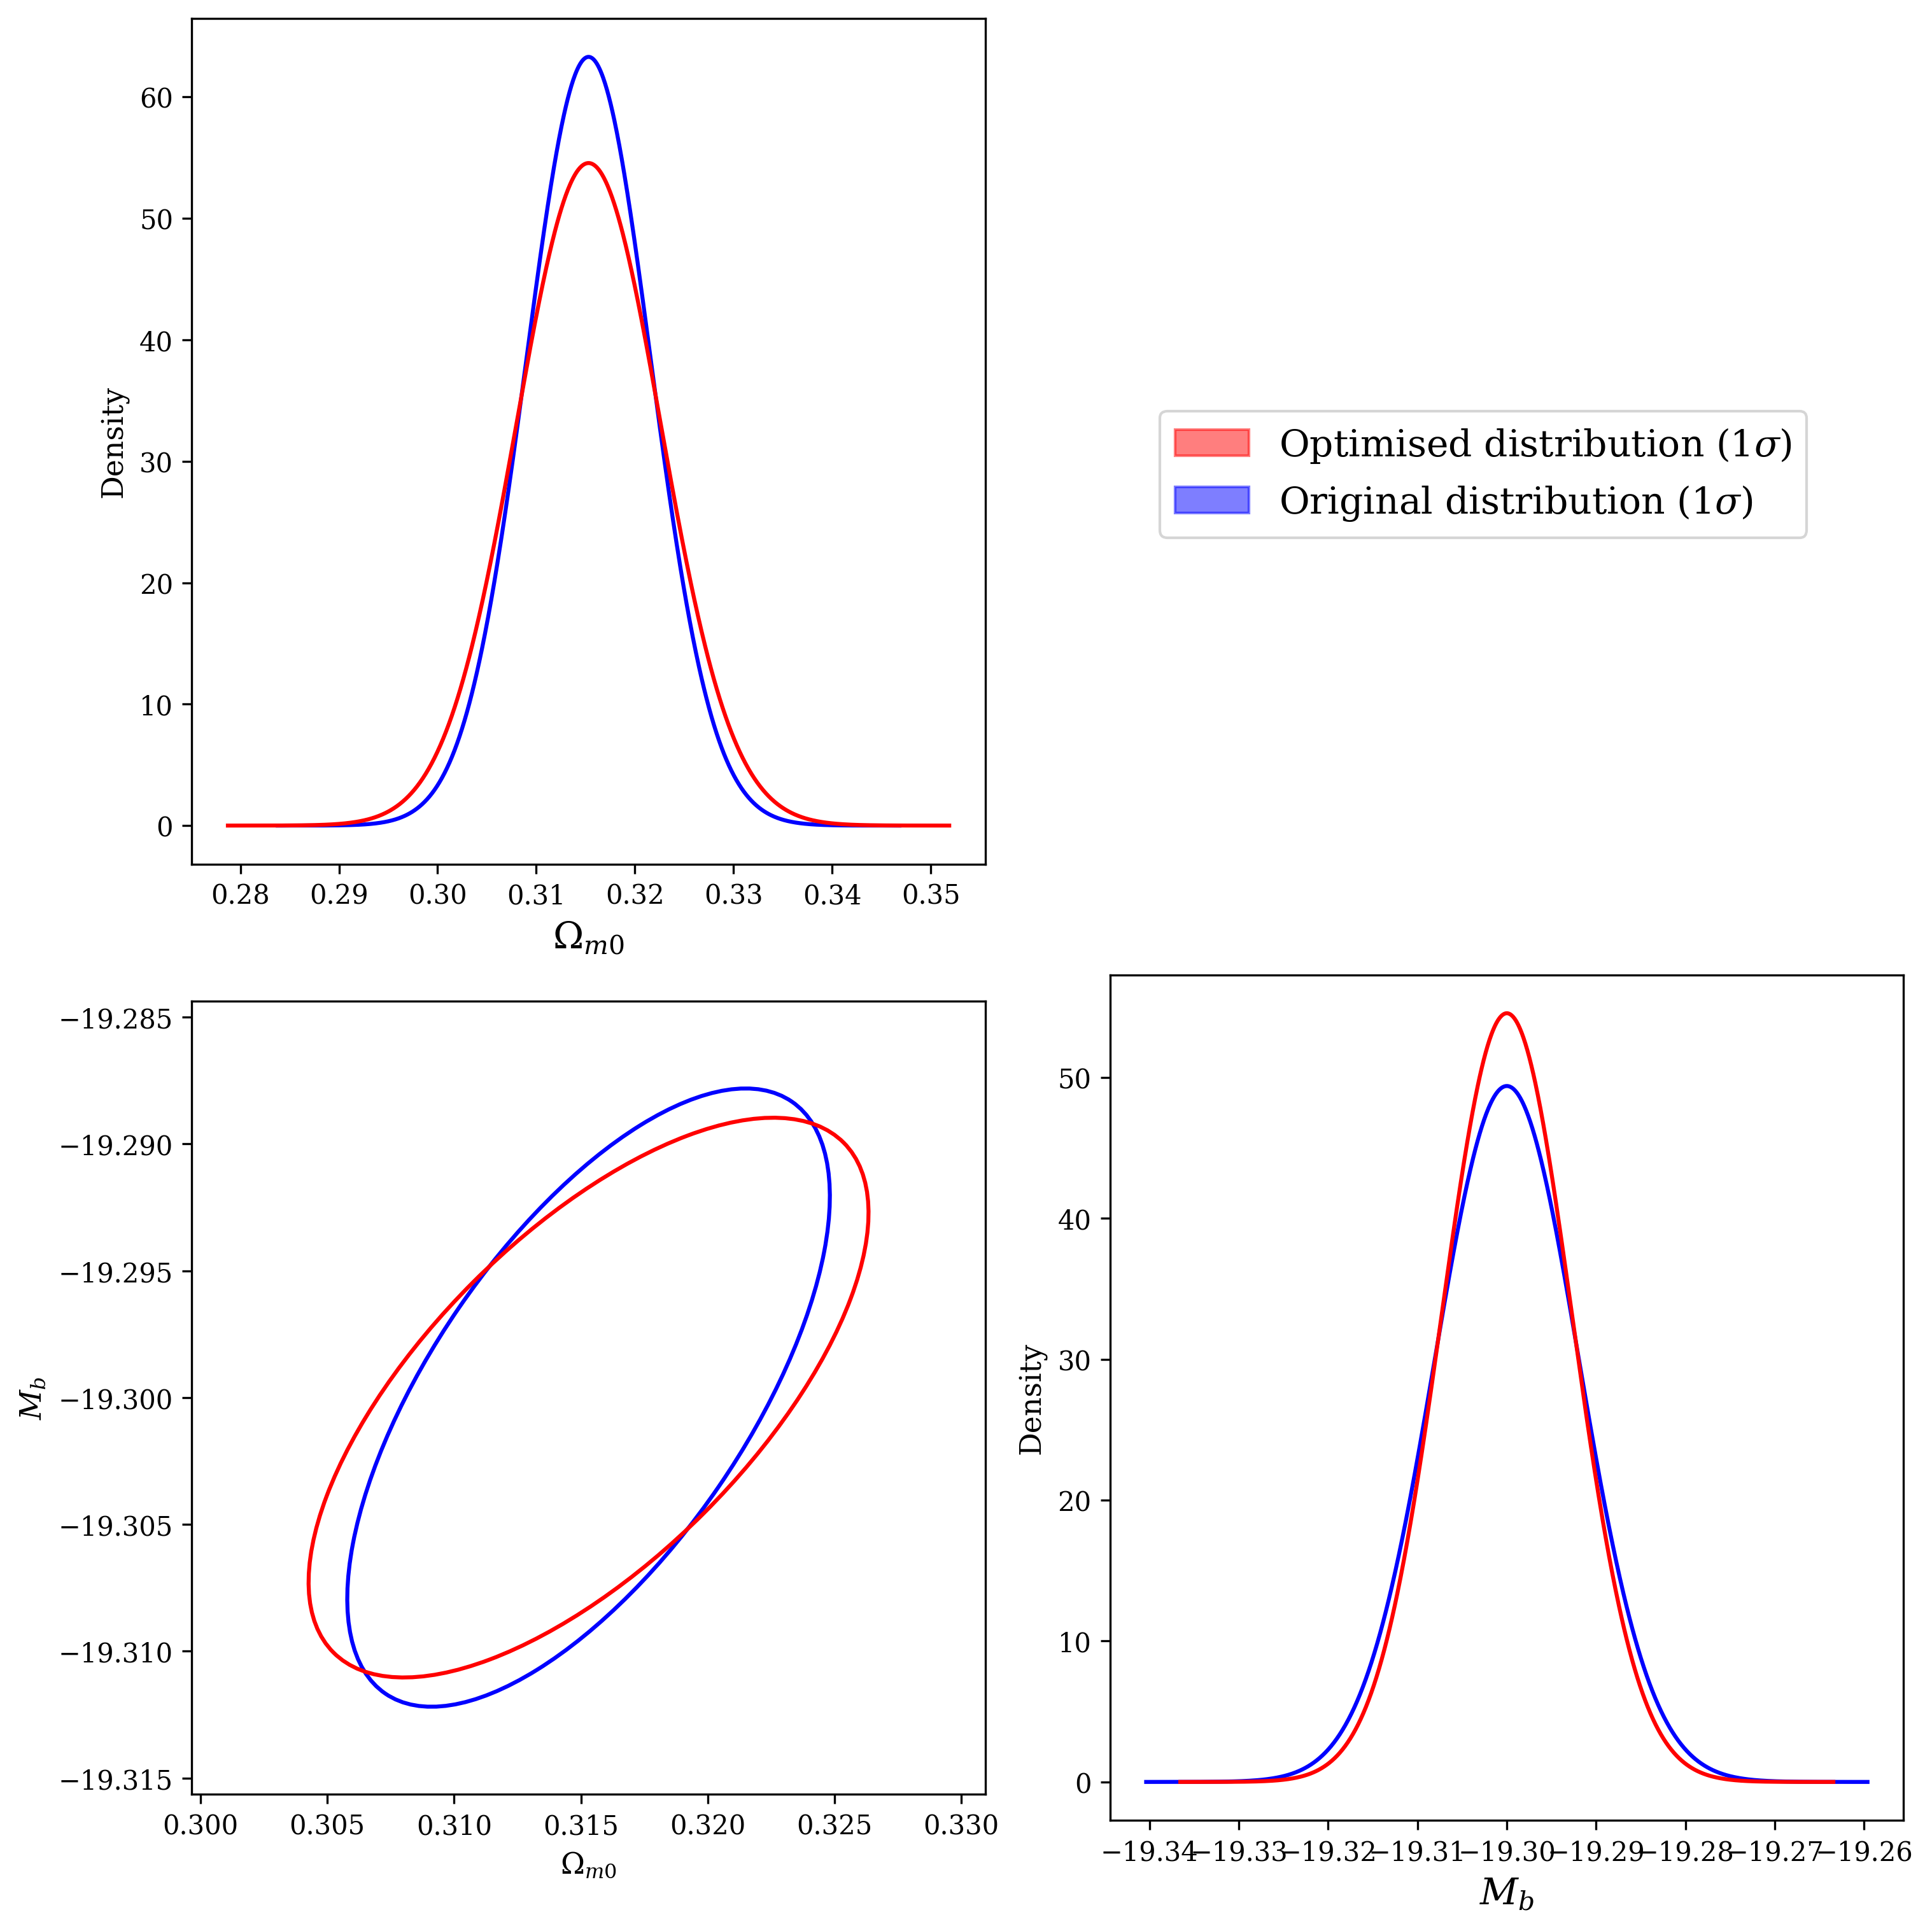

In [74]:
fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)
# original fisher matrix
fma.add_fisher_to_plot(
        FF,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='blue',
        filled=False,
        param_labels=param_labels
    )

# fma.add_fisher_to_plot(
#         track_FF[0],
#         fiducial_param=fiducial_param,
#         axs_2d=axs_2d,
#         axs_1d=axs_1d,
#         param_indices=param_indices,
#         alpha_values=[0.32],
#         color='orange',
#         filled=False,
#         param_labels=param_labels
#     )
fma.add_fisher_to_plot(
        track_FF[-1],
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='red',
        filled=False,
        param_labels=param_labels
    )

# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='red', edgecolor='red', alpha=0.5, label=r'Optimised distribution (1$\sigma$)'),
    Patch(facecolor='blue', edgecolor='blue', alpha=0.5, label=r'Original distribution (1$\sigma$)')]#,
    # Patch(facecolor='orange', edgecolor='orange', alpha=0.5, label=r'First iteration (1$\sigma$)')]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)
#plt.savefig('figures/ellispes_comparison_roman_100')
# Show the final overlaid plot
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


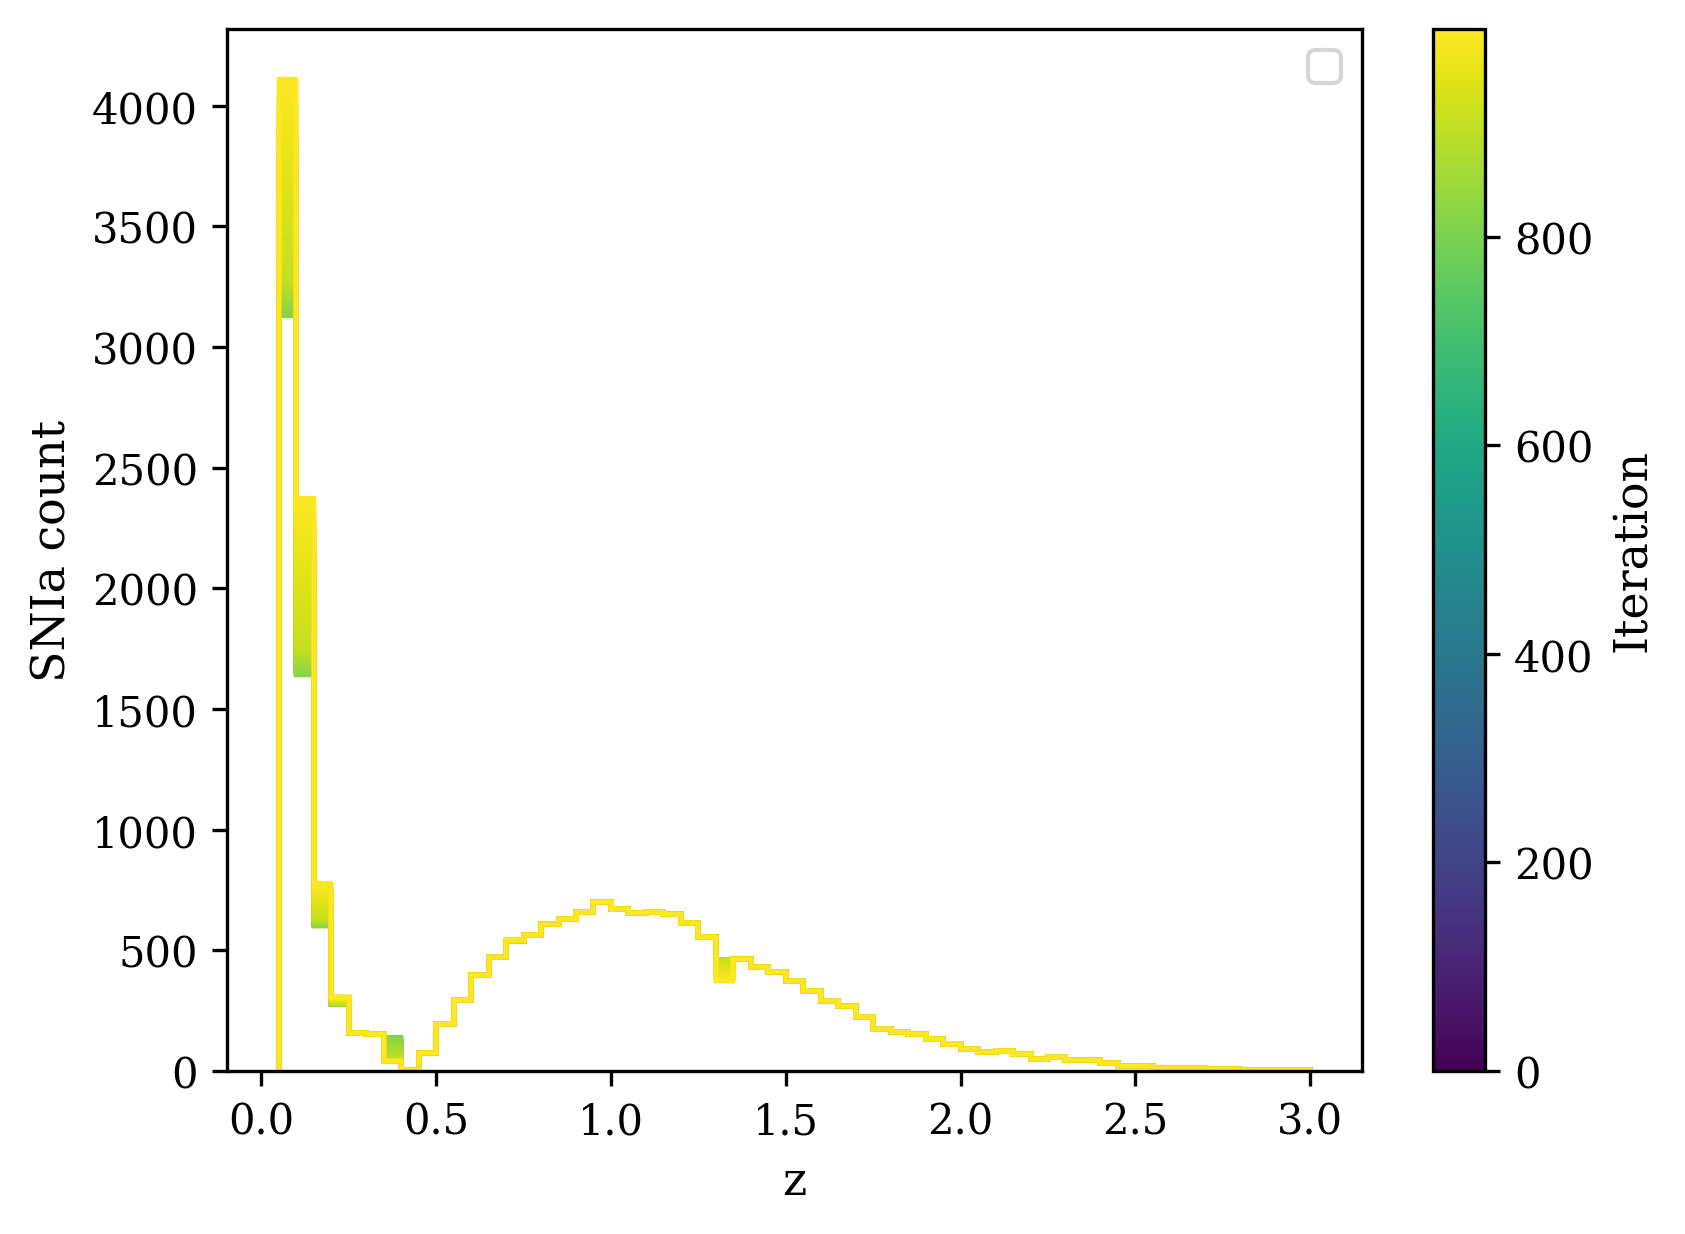

In [75]:
# plot
cmap = plt.cm.viridis  # choose any colormap you like
norm = plt.Normalize(vmin=0, vmax=nb_iter-1)

for ii in range(809,track_Cov.shape[0]):
    plt.stairs(track_distribution[ii], z_edges,
                color=cmap(norm(ii)))

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             label='Iteration')

plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


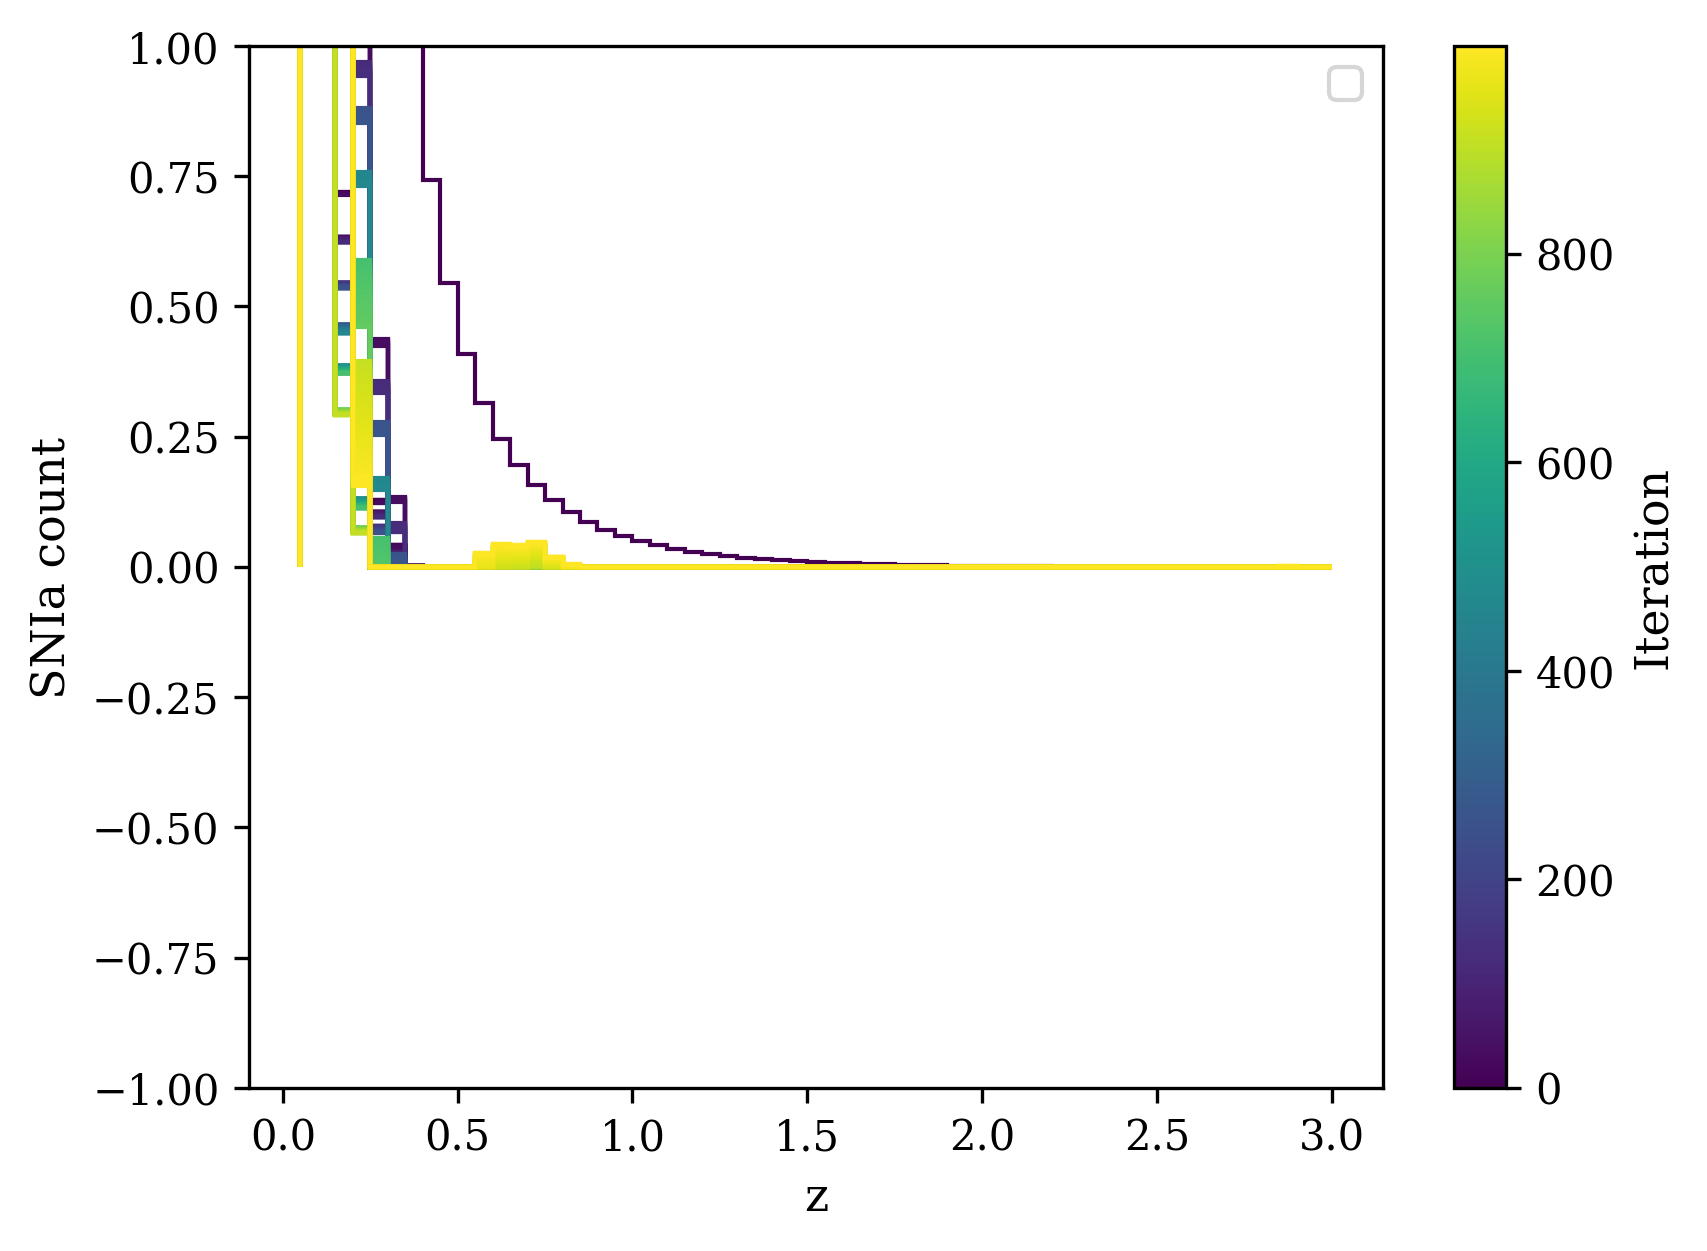

In [76]:
# plot
cmap = plt.cm.viridis  # choose any colormap you like
norm = plt.Normalize(vmin=0, vmax=nb_iter-1)

for ii in range(track_Cov.shape[0]):
    plt.stairs(track_delta_n[ii], z_edges,
                color=cmap(norm(ii)))

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             label='Iteration')
plt.ylim(-1,1)
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.show()

In [77]:
for i, cc in enumerate(track_Cov):
    print(fma.is_positive_definite(cc))
    if not fma.is_positive_definite(cc):
        print(f"First False at index {i}")
        break
else:
    print("All matrices are positive definite")

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [78]:
track_Cov.shape

(1000, 59, 59)

In [79]:
np.diag(Cov_roman)

array([1.01102110e-04, 4.38097170e-04, 2.67781948e-04, 2.12293430e-04,
       1.78580487e-04, 1.50286807e-04, 1.30170764e-04, 1.15121023e-04,
       1.05215271e-04, 9.58884371e-05, 8.78164854e-05, 8.18840487e-05,
       7.75485222e-05, 7.33808687e-05, 7.28130164e-05, 7.06851177e-05,
       6.99468271e-05, 6.92797384e-05, 6.88341708e-05, 7.04917611e-05,
       7.74284605e-05, 8.08974903e-05, 8.51519959e-05, 9.07703079e-05,
       9.93513950e-05, 1.07590406e-04, 1.14638969e-04, 1.27943105e-04,
       1.37640055e-04, 1.49264615e-04, 1.64199699e-04, 1.76866301e-04,
       1.91333150e-04, 2.12087178e-04, 2.39550878e-04, 2.67274781e-04,
       2.88418189e-04, 3.37065172e-04, 3.88180139e-04, 4.41800822e-04,
       5.10448613e-04, 5.33416969e-04, 6.19965846e-04, 7.69870490e-04,
       7.23886807e-04, 9.38480862e-04, 9.60855501e-04, 1.37024124e-03,
       1.93496870e-03, 2.27317575e-03, 5.10653512e-03, 6.48969734e-03,
       6.32528797e-03, 8.07638081e-03, 9.50480399e-03, 2.23665375e-02,
      

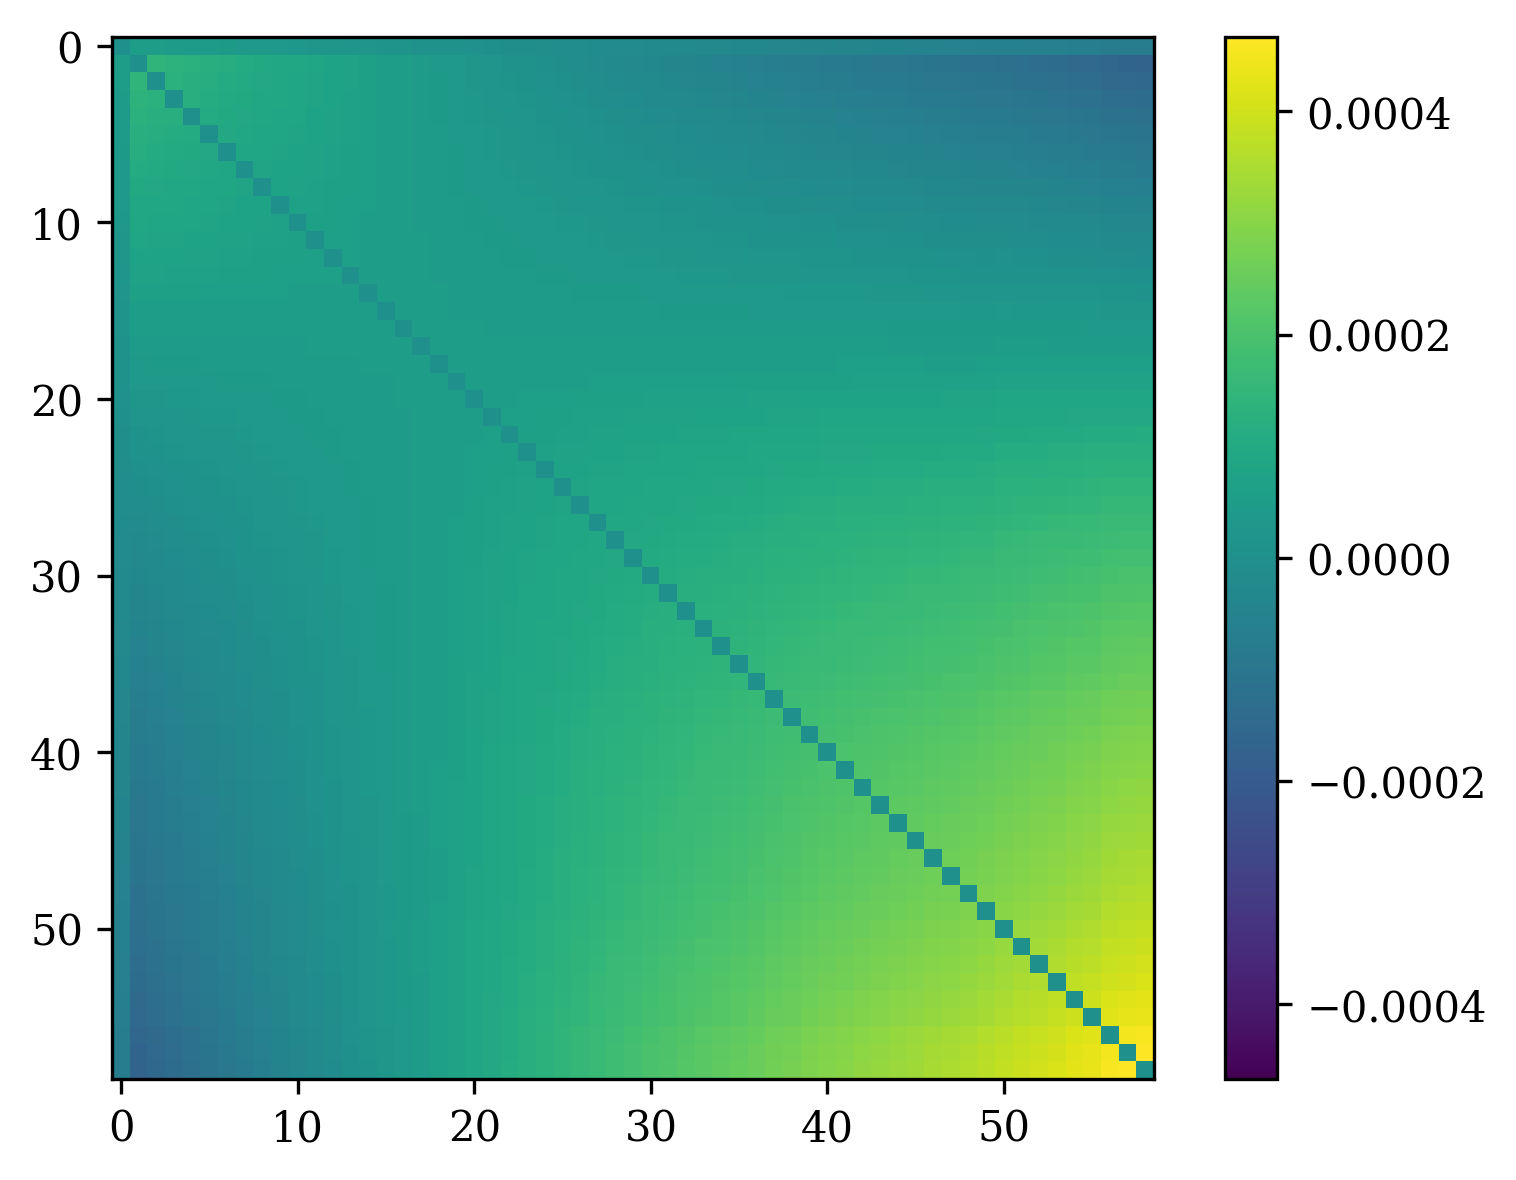

In [80]:
cc_sys = Cov_roman-np.diag(np.diag(Cov_roman))
vmin=np.min(cc_sys)
vmax=np.max(cc_sys)
norm = colors.Normalize(vmin=-max(np.abs(vmin),np.abs(vmax)), 
                        vmax=max(np.abs(vmin),np.abs(vmax)))

plt.imshow(cc_sys,norm=norm)

plt.colorbar()

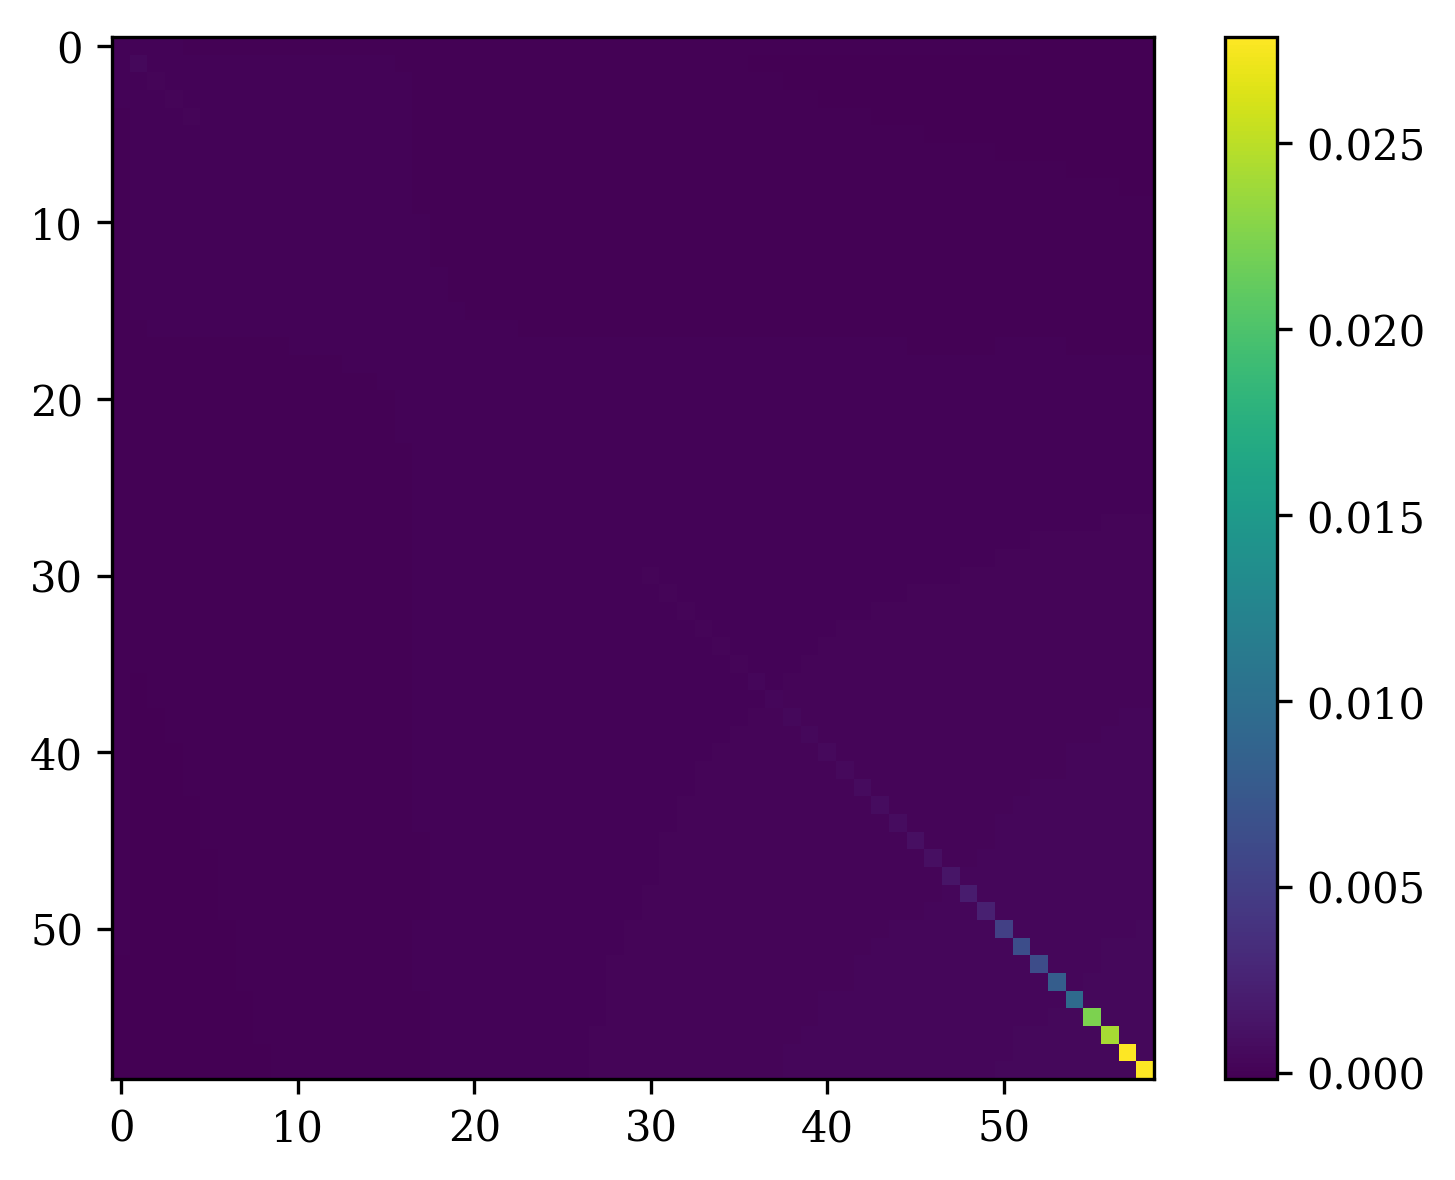

In [81]:
Cov_roman1 = track_Cov[0]
Cov_roman2 = track_Cov[1]

norm = colors.Normalize(vmin=np.min(Cov_roman), vmax=np.max(Cov_roman))

plt.imshow(Cov_roman1,norm=norm)
plt.colorbar()